# Sales-Method Performance Over A Six-Week Product Campaign

**Originally reported:** August 2024  
**Revised:** October 2026

This report revisits the original analysis to correct data handling,
refine revenue estimation, and improve the interpretation and presentation
of results. The revision uses the original dataset; October 2026 is the
revision date, not a new observation period.

## Project background

This dataset was provided by DataCamp in August 2024. This records the receipt date, not verified campaign dates. The CSV identifies relative weeks 1–6 but contains no calendar dates. The original task brief and data dictionary should be archived alongside the project when available. Until then, the company's stated 1984 founding year and the 2024 tenure reference year are treated as analytical assumptions.

Pens and Printers, founded in 1984, provides high-quality office products to large organisations. This analysis compares customer records associated with three sales approaches: Email, Call, and Email + Call. The business objective is to understand revenue performance and inform the next campaign.

The analysis separates customer volume, revenue per customer, and total revenue. A method can generate higher average spending without producing the highest total, and a rising average does not necessarily indicate business-wide revenue growth. The available records do not establish conversion rates, profitability, or causal effects of sales method.

Insights and recommendations are provided across the following key areas:
- **Data Quality and Revenue Estimation:** Validation of customer records, correction of invalid values, and estimation of missing revenue with prediction-error checks.
- **Sales-Method Comparison:** Comparison of customer counts, recorded revenue distributions, and estimated revenue totals across Email, Call, and Email + Call.
- **Weekly Sales Trends:** Evaluation of customer volume, revenue per customer, total revenue, and growth, distinguishing observed results from estimates.
- **Business Performance Metrics:** Definition of revenue, customer-volume, spending, and data-completeness measures, supported by historical baselines.
- **Recommendations and Further Measurement:** Identification of follow-up opportunities and the additional data needed to assess conversion, staff efficiency, and profitability.

## Data quality

### Data structure & initial checks

The source CSV contains 15,000 customer records and eight columns covering campaign week, sales method, customer identifier, quantity sold, revenue, customer tenure, website visits, and state. The following cell imports the data and preserves an unchanged copy in `raw_sales_data`; subsequent preparation uses `sales_data`.

The source uses `NA` for missing revenue. Revenue is reported in the dataset's units because a currency has not been established. Customer-level measures are used rather than average order value, since the records do not establish an order-level denominator.

In [1]:
# Import packages and configure the current checkout explicitly.
import sys
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator, PercentFormatter, StrMethodFormatter

# Run from the repository root or its notebook directory.
# For another launch location, replace Path.cwd() with the intended root path.
project_root = Path.cwd().resolve()
if project_root.name == "2 Notebook":
	project_root = project_root.parent
dataset_path = project_root / "0 Data" / "product_sales.csv"
if not dataset_path.is_file():
	raise FileNotFoundError(
		"Set project_root to the repository containing 0 Data/product_sales.csv."
	)

# Create output folders only after confirming the input location.
figures_path = project_root / "3 Reports" / "0 Figures"
tables_path = project_root / "3 Reports" / "1 Tables"
figures_path.mkdir(parents=True, exist_ok=True)
tables_path.mkdir(parents=True, exist_ok=True)

# Keep shared definitions in one place for validation and presentation.
sales_method_order = ["Call", "Email", "Email + Call"]
expected_sales_methods = set(sales_method_order)
sales_method_corrections = {
	"email": "Email",
	"em + call": "Email + Call",
}
sales_method_colours = {
	"Call": "#83BBF3",
	"Email": "#8DE099",
	"Email + Call": "#E76868",
}
sales_method_markers = {"Call": "o", "Email": "s", "Email + Call": "D"}
sales_method_dashes = {
	"Call": "",
	"Email": (4, 2),
	"Email + Call": (1, 2),
}
expected_weeks = list(range(1, 7))

# Tolerances measure arithmetic agreement, not statistical uncertainty.
revenue_reconciliation_tolerance = 0.01
mean_reconciliation_tolerance = 1e-10
percentage_reconciliation_tolerance = 1e-8

# The founding year and tenure reference year are documented assumptions.
# Dataset receipt in 2024 does not establish the observation dates.
dataset_reference_year = 2024
company_founding_year = 1984
maximum_customer_tenure = dataset_reference_year - company_founding_year

# Preserve imported values; cleaning operates on a separate working frame.
raw_sales_data = pd.read_csv(
	dataset_path,
	encoding="utf-8",
	keep_default_na=True,
)
sales_data = raw_sales_data.copy(deep=True)
print(
	f"Imported {len(raw_sales_data):,} customer records "
	f"and {len(raw_sales_data.columns)} columns."
)
display(raw_sales_data.head())

Imported 15,000 customer records and 8 columns.


,week,sales_method,customer_id,nb_sold,revenue,years_as_customer,nb_site_visits,state
0,2,Email,2e72d641-95ac-497b-bbf8-4861764a7097,10,NaN,0,24,Arizona
1,6,Email + Call,3998a98d-70f5-44f7-942e-789bb8ad2fe7,15,225.47,1,28,Kansas
2,5,Call,d1de9884-8059-4065-b10f-86eef57e4a44,11,52.55,6,26,Wisconsin
3,4,Email,78aa75a4-ffeb-4817-b1d0-2f030783c5d7,11,NaN,3,25,Indiana
4,3,Email,10e6d446-10a5-42e5-8210-1b5438f70922,9,90.49,0,28,Illinois


### Software environment

The table records the Python and principal package versions used for this execution. Run the notebook from the repository root or its `2 Notebook` directory. If launched elsewhere, explicitly set `project_root` in the first code cell to the intended checkout. The environment specification records installation dependencies; it does not prove that a fresh installation has been tested on every platform.

In [2]:
# Record the actual environment running this notebook.
environment_versions = pd.DataFrame(
	{
		"Package": [
			"Python",
			"pandas",
			"NumPy",
			"Matplotlib",
			"Seaborn",
		],
		"Version": [
			sys.version.split()[0],
			pd.__version__,
			np.__version__,
			matplotlib.__version__,
			sns.__version__,
		],
	}
)

display(environment_versions)

# Save alongside the shared analysis tables.
environment_versions.to_csv(
	f"{tables_path}/Table 01 Environment Versions.csv",
	index=False,
)

,Package,Version
0,Python,3.13.13
1,pandas,3.0.6
2,NumPy,2.5.3
3,Matplotlib,3.11.2
4,Seaborn,0.13.2


### Data Validation

Before correcting values, the following cell checks the schema, missingness, duplicate rows, customer identifiers, numeric validity, and category labels. It leaves `sales_data` unchanged.

- **Week:** whole numbers from 1 to 6.
- **Sales method:** the expected labels are Email, Call, and Email + Call; spelling variants are identified before correction.
- **Customer identifier:** non-missing, non-blank, and unique values.
- **Quantity sold:** positive whole numbers; the observed range is reported rather than imposed as an undocumented rule.
- **Revenue:** missing values, non-numeric entries, infinite values, and negative amounts are checked.
- **Customer tenure:** whole numbers from 0 to 40, using the stated 1984 founding year and an assumed 2024 tenure reference year. The resulting maximum is 40 years. The receipt date does not independently verify the tenure reference date; confirm it against the original task brief. The 2026 revision date is not used to increase the bound.
- **Website visits:** non-negative whole numbers.
- **State:** missing values and labels outside the 50 US states are checked.

The saved results identify 1,074 missing revenues, two invalid tenure values, and two alternative sales-method spellings. There are no duplicate rows or duplicate customer identifiers. Missingness is also examined by method and week; temporary label standardisation in the diagnostic copy prevents spelling variants from splitting the method counts.

In [3]:
# Stop before validation if there are no records or column names are ambiguous.
if sales_data.empty:
	raise ValueError("The dataset contains no customer records.")

if sales_data.columns.duplicated().any():
	duplicate_column_names = sales_data.columns[
		sales_data.columns.duplicated(keep=False)
	].tolist()
	raise ValueError(
		f"Duplicate column names found: {duplicate_column_names}"
	)

# Confirm all expected columns are present and raise error if any unexpected
# columns are found.
expected_columns = {
	"week",
	"sales_method",
	"customer_id",
	"nb_sold",
	"revenue",
	"years_as_customer",
	"nb_site_visits",
	"state",
}

# Validate the schema before checking values within individual columns.
missing_columns = expected_columns - set(sales_data.columns)
unexpected_columns = set(sales_data.columns) - expected_columns

if missing_columns:
	raise ValueError(
		f"Required columns are missing: {sorted(missing_columns)}"
	)

if unexpected_columns:
	raise ValueError(
		f"Unexpected columns found: {sorted(unexpected_columns)}"
	)

# Revenue may be missing and estimated later.
# Customer tenure may be missing when its true value cannot be established.
required_non_missing_columns = [
	"week",
	"sales_method",
	"customer_id",
	"nb_sold",
	"nb_site_visits",
	"state",
]

required_missing_counts = (
	sales_data[required_non_missing_columns].isna().sum()
)
required_missing_counts = required_missing_counts[
	required_missing_counts.gt(0)
]

if not required_missing_counts.empty:
	raise ValueError(
		"Required columns contain missing values: "
		f"{required_missing_counts.to_dict()}"
	)

# Summarise completeness and data types.
column_summary = pd.DataFrame(
	{
		"Data Type": sales_data.dtypes.astype(str),
		"Missing Count": sales_data.isna().sum(),
		"Missing Percentage (%)": 	sales_data.isna().mean() * 100,
		"Unique Non-Missing Values": sales_data.nunique(dropna=True),
		}
		)
print("\nColumn data quality summary:")
display(column_summary.round({"Missing Percentage (%)": 2}))

# Distinguish duplicate records from repeated customer identifiers.
customer_identifiers = sales_data["customer_id"].astype("string")
blank_customer_identifiers = (
	customer_identifiers.str.strip().eq("").fillna(False)
)
duplicate_customer_identifiers = (
	customer_identifiers.notna()
	& ~blank_customer_identifiers
	& customer_identifiers.duplicated(keep=False)
	)

print("\nExact duplicate rows beyond the first occurrence:", sales_data.duplicated().sum(),)
print("Missing customer identifiers:", customer_identifiers.isna().sum(),)
print("Blank customer identifiers:", blank_customer_identifiers.sum(),)
print("Rows sharing a non-blank customer identifier:", duplicate_customer_identifiers.sum(),)

# Check numeric columns for non-numeric, non-finite, and out-of-range values.
numeric_columns = [
	"week",
	"nb_sold",
	"revenue",
	"years_as_customer",
	"nb_site_visits",
	]
whole_number_columns = [
	"week",
	"nb_sold",
	"years_as_customer",
	"nb_site_visits",
	]

numeric_values = sales_data[numeric_columns].apply(
	pd.to_numeric,
	errors="coerce",
	)
non_numeric_values = (
	sales_data[numeric_columns].notna()
	& numeric_values.isna()
	)
non_finite_values = (
	numeric_values.notna()
	& ~np.isfinite(numeric_values)
	)

numeric_summary = pd.DataFrame(
	{
		"Minimum": numeric_values.min(),
		"Maximum": numeric_values.max(),
		"Non-Numeric Count": non_numeric_values.sum(),
		"Non-Finite Count": non_finite_values.sum(),
		}
		)
print("\nNumeric column summary:")
display(numeric_summary)

fractional_values = (
	numeric_values[whole_number_columns].notna()
	& np.isfinite(numeric_values[whole_number_columns])
	& numeric_values[whole_number_columns].mod(1).ne(0)
	)
print("\nNon-integer counts for whole-number columns:")
display(fractional_values.sum().rename("Non-Integer Count").to_frame())

# Flag values outside documented or logically valid bounds.
# Apply the shared tenure bound; its reference year is an assumption.

invalid_numeric_values = pd.DataFrame(
	{
		"week": (
			numeric_values["week"].notna()
			& ~numeric_values["week"].between(1, 6)
		),
		"nb_sold": numeric_values["nb_sold"].le(0),
		"revenue": numeric_values["revenue"].lt(0),
		"years_as_customer": (
			numeric_values["years_as_customer"].notna()
			& ~numeric_values["years_as_customer"].between(
				0,
				maximum_customer_tenure,
			)
		),
		"nb_site_visits": numeric_values["nb_site_visits"].lt(0),
	}
)

print("\nOut-of-range values by column:")
display(
	invalid_numeric_values.sum().rename("Out-of-Range Count").to_frame()
)

numeric_issue_rows = (
	non_numeric_values.any(axis=1)
	| non_finite_values.any(axis=1)
	| fractional_values.any(axis=1)
	| invalid_numeric_values.any(axis=1)
)
print("\nRows with numeric issues:")
display(sales_data.loc[numeric_issue_rows])

# Inspect labels before applying any spelling corrections.
print("\nSales-method label counts:")
display(
	sales_data["sales_method"]
	.value_counts(dropna=False)
	.rename("Record Count")
	.to_frame()
)

unexpected_sales_methods = (
	sales_data["sales_method"].notna()
	& ~sales_data["sales_method"].isin(expected_sales_methods)
)
print(
	"\nUnexpected sales-method labels:",
	sales_data.loc[
		unexpected_sales_methods, "sales_method"
	].unique().tolist(),
)

expected_states = set(
	"Alabama|Alaska|Arizona|Arkansas|California|Colorado|Connecticut|"
	"Delaware|Florida|Georgia|Hawaii|Idaho|Illinois|Indiana|Iowa|"
	"Kansas|Kentucky|Louisiana|Maine|Maryland|Massachusetts|Michigan|"
	"Minnesota|Mississippi|Missouri|Montana|Nebraska|Nevada|"
	"New Hampshire|New Jersey|New Mexico|New York|North Carolina|"
	"North Dakota|Ohio|Oklahoma|Oregon|Pennsylvania|Rhode Island|"
	"South Carolina|South Dakota|Tennessee|Texas|Utah|Vermont|"
	"Virginia|Washington|West Virginia|Wisconsin|Wyoming".split("|")
)

unexpected_states = (
	sales_data["state"].notna()
	& ~sales_data["state"].isin(expected_states)
)
print(
	"\nUnexpected state labels:",
	sales_data.loc[unexpected_states, "state"].unique().tolist(),
)

# Compare missingness using temporary standardised method labels.
validation_data = sales_data.assign(
	validated_sales_method=sales_data["sales_method"].replace(
		sales_method_corrections
	),
	revenue_missing=sales_data["revenue"].isna(),
)

for grouping_column in ["validated_sales_method", "week"]:
	missing_revenue_summary = (
		validation_data.groupby(
			grouping_column,
			dropna=False,
			observed=True,
			)
			.agg(
				record_count=("revenue_missing", "size"),
				missing_revenue_count=("revenue_missing", "sum"),
				)
				)
	missing_revenue_summary = missing_revenue_summary.rename(columns={
		"missing_revenue_count": "Missing Revenue Count",
		"record_count": "Record Count"
	})
	missing_revenue_summary["Missing Revenue Percentage (%)"] = (
		missing_revenue_summary["Missing Revenue Count"]
		/ missing_revenue_summary["Record Count"]
		* 100
		)
	print(f"\nMissing revenue summary by {grouping_column}:")
	display(
			missing_revenue_summary.round(
				{"Missing Revenue Percentage (%)": 2}
				)
				)


Column data quality summary:


,Data Type,Missing Count,Missing Percentage (%),Unique Non-Missing Values
week,int64,0,0.00,6
sales_method,str,0,0.00,5
customer_id,str,0,0.00,15000
nb_sold,int64,0,0.00,10
revenue,float64,1074,7.16,6743
years_as_customer,int64,0,0.00,42
nb_site_visits,int64,0,0.00,27
state,str,0,0.00,50



Exact duplicate rows beyond the first occurrence: 0
Missing customer identifiers: 0
Blank customer identifiers: 0
Rows sharing a non-blank customer identifier: 0

Numeric column summary:


,Minimum,Maximum,Non-Numeric Count,Non-Finite Count
week,1.00,6.00,0,0
nb_sold,7.00,16.00,0,0
revenue,32.54,238.32,0,0
years_as_customer,0.00,63.00,0,0
nb_site_visits,12.00,41.00,0,0



Non-integer counts for whole-number columns:


...

,Record Count
sales_method,
Email,7456
Call,4962
Email + Call,2549
em + call,23
email,10



Unexpected sales-method labels: ['em + call', 'email']

Unexpected state labels: []

Missing revenue summary by validated_sales_method:


,Record Count,Missing Revenue Count,Missing Revenue Percentage (%)
validated_sales_method,,,
Call,4962,181,3.65
Email,7466,544,7.29
Email + Call,2572,349,13.57



Missing revenue summary by week:


,Record Count,Missing Revenue Count,Missing Revenue Percentage (%)
week,,,
1,3721,224,6.02
2,2491,168,6.74
3,2411,154,6.39
4,2575,188,7.30
5,2574,208,8.08
6,1228,132,10.75


### Data correction

The validation results identify `email` and `em + call` as spelling variants. The following cell maps these to `Email` and `Email + Call`, respectively.

Customer tenures of 47 and 63 exceed the assumed maximum of 40 years using the stated 1984 founding year and 2024 reference year. Their correct values are unknown, so they are set to `pd.NA` in the working dataset. Both customer records are retained, and the original values remain in `raw_sales_data`. Tenure is not used in the revenue calculations.

Validated week, quantity, and visit counts use `int8`; tenure uses nullable `Int8` to retain its missing values. Sales method and state are categorical, while revenue retains decimal precision. The cell then checks the corrected categories, tenure missingness, and data types.

In [4]:
# Validation identifies problems; stop before conversion if unresolved issues
# remain.
# Out-of-range tenure is the documented exception corrected below.
if non_numeric_values.any().any() or non_finite_values.any().any():
	raise ValueError("Resolve non-numeric or infinite values before correction.")
if fractional_values.any().any():
	raise ValueError("Resolve fractional values in whole-number columns.")
if invalid_numeric_values.drop(columns="years_as_customer").any().any():
	raise ValueError("Resolve invalid numeric values other than customer tenure.")
if blank_customer_identifiers.any() or duplicate_customer_identifiers.any():
	raise ValueError("Resolve blank or duplicate customer identifiers.")
if unexpected_states.any():
	raise ValueError("Resolve unexpected state labels before correction.")

# Apply only the sales-method spelling corrections identified in validation.
sales_data["sales_method"] = sales_data["sales_method"].replace(
	sales_method_corrections
)

if not sales_data["sales_method"].isin(expected_sales_methods).all():
	raise ValueError("Unrecognised sales methods remain after correction.")

# Convert validated whole-number columns.
integer_columns = [
	"week",
	"nb_sold",
	"nb_site_visits",
]
# Check numeric values before narrowing storage; prevent integer overflow.
integer_storage_limits = np.iinfo(np.int8)
validated_integer_values = numeric_values[integer_columns]

if (
	validated_integer_values.lt(integer_storage_limits.min).any().any()
	or validated_integer_values.gt(integer_storage_limits.max).any().any()
):
	raise ValueError(
		"An integer value exceeds the int8 range; use a wider type."
	)

sales_data[integer_columns] = validated_integer_values.astype("int8")

# Retain each customer record, but remove tenure values whose replacements
# cannot be established from the available evidence.
validated_customer_tenure = numeric_values["years_as_customer"]

sales_data["years_as_customer"] = (
	validated_customer_tenure.mask(
		validated_customer_tenure.notna()
		& ~validated_customer_tenure.between(
			0,
			maximum_customer_tenure,
		),
		pd.NA,
	)
	.astype("Int8")
)

# Preserve missing revenue and its decimal precision.
sales_data["revenue"] = numeric_values["revenue"].astype("float64")

# Store repeated labels as categories after standardising their spelling.
categorical_columns = ["sales_method", "state"]
sales_data[categorical_columns] = sales_data[categorical_columns].astype(
	"category"
)

# Check the corrected labels and missing tenure count before further analysis.
print("Sales-method label counts after correction:")
display(
	sales_data["sales_method"]
	.value_counts(dropna=False)
	.rename("Customer Count")
	.to_frame()
)
print(
	"\nMissing customer-tenure values after correction:",
	sales_data["years_as_customer"].isna().sum(),
)
display(sales_data.dtypes.rename("data_type").to_frame())

Sales-method label counts after correction:


,Customer Count
sales_method,
Email,7466
Call,4962
Email + Call,2572



Missing customer-tenure values after correction: 2


,data_type
week,int8
sales_method,category
customer_id,str
nb_sold,int8
revenue,float64
years_as_customer,Int8
nb_site_visits,int8
state,category


### Estimating missing revenue and checking prediction error

Recorded revenue is missing for 1,074 customers (7.16%). The original `revenue` column retains these missing values. A separate `estimated_revenue` column preserves recorded amounts and fills missing amounts using mean recorded revenue within sales method, quantity sold, and campaign week.

- **Sales method** distinguishes groups with substantially different observed revenues; customer engagement and purchasing behaviour may differ between approaches.
- **Quantity sold** directly contributes to revenue alongside prices and adjustments.
- **Week** compares customers at the same campaign stage, without assuming that effectiveness necessarily improved over time.

Website visits, tenure, and state are omitted to keep the estimate straightforward and avoid unnecessarily small groups. The documentation does not establish additional pricing effects from these variables; their omission does not prove they have no relationship with revenue.

The central assumption is that missing and recorded revenues have similar means within the selected groups. If an exact group lacks recorded revenue, the code falls back to sales method and quantity, then sales method alone. The estimate source and supporting record count are retained for inspection.

Before estimating genuinely missing amounts, the code withholds approximately 20% of recorded revenues within each method. Group averages are fitted on the remaining records and used to predict the withheld amounts. It reports mean absolute error (MAE), root mean squared error (RMSE), and mean signed error; positive signed error indicates overprediction. A second set of scores weights method-level errors by each method's share of missing records, rather than by its missingness rate.

The saved run reports MAE of 1.466 and RMSE of 1.946 revenue units; weighting to the missing-record method mix gives 1.643 and 2.113. All 1,074 final estimates use the exact method–quantity–week grouping. One estimate is supported by only three recorded revenues and warrants particular caution. These checks assess prediction on recorded revenues; they do not verify the missingness assumption or provide confidence intervals for estimated totals.

Fallbacks apply to groups without a recorded mean, not automatically to small groups. The separate repeated-holdout comparison below checks estimator stability and whether including week improves prediction over simpler grouping rules. It does not automatically replace the estimator used for campaign totals.

In [5]:
# Preserve revenue; estimated_revenue contains recorded values plus estimates.
def estimate_missing_revenue(
	reference_data, target_data, grouping_levels=None
):
	"""Use group means, falling back only when recorded support is absent."""
	if grouping_levels is None:
		grouping_levels = [
			["sales_method", "nb_sold", "week"],
			["sales_method", "nb_sold"],
			["sales_method"],
		]
	predictions = pd.DataFrame(index=target_data.index)
	predictions["Predicted Revenue"] = np.nan
	predictions["Estimate Source"] = pd.Series(
		pd.NA, index=target_data.index, dtype="string"
	)
	predictions["Support Count"] = pd.Series(
		pd.NA, index=target_data.index, dtype="Int64"
	)
	for grouping_columns in grouping_levels:
		# Stop once every target has a prediction; join unresolved rows only.
		unresolved_predictions = predictions["Predicted Revenue"].isna()
		if not unresolved_predictions.any():
			break
		group_statistics = reference_data.groupby(
			grouping_columns, observed=True
		)["revenue"].agg(group_mean="mean", group_count="count")
		matched_statistics = target_data.loc[
			unresolved_predictions, grouping_columns
		].join(
			group_statistics, on=grouping_columns
		)
		available_predictions = matched_statistics.index[
			matched_statistics["group_mean"].notna()
		]
		predictions.loc[available_predictions, "Predicted Revenue"] = (
			matched_statistics.loc[available_predictions, "group_mean"]
		)
		predictions.loc[available_predictions, "Estimate Source"] = (
			" + ".join(grouping_columns)
		)
		predictions.loc[available_predictions, "Support Count"] = (
			matched_statistics.loc[available_predictions, "group_count"].astype(
				"Int64"
			)
		)
	if predictions["Predicted Revenue"].isna().any():
		raise ValueError("Some records have no recorded revenue in their sales method.")
	return predictions


missing_revenue = sales_data["revenue"].isna()
observed_sales = sales_data.loc[~missing_revenue].copy()
if not np.isfinite(observed_sales["revenue"]).all():
	raise ValueError("Resolve non-finite recorded revenues before estimation.")

# Use one reproducible 80/20 split within each method for a simple validation.
# No withheld revenue contributes to training averages or fallback averages.
validation_fraction = 0.20
random_generator = np.random.default_rng(20241004)
validation_indices = []
for sales_method, method_records in observed_sales.groupby(
	"sales_method", observed=True
):
	if len(method_records) < 2:
		raise ValueError(f"Too few recorded revenues to validate {sales_method}.")
	validation_count = min(
		len(method_records) - 1,
		max(1, int(round(len(method_records) * validation_fraction))),
	)
	validation_indices.extend(
		random_generator.choice(
			method_records.index.to_numpy(), size=validation_count, replace=False
		).tolist()
	)

validation_sales = observed_sales.loc[validation_indices].copy()
training_sales = observed_sales.drop(index=validation_indices)
validation_predictions = estimate_missing_revenue(training_sales, validation_sales)
validation_results = validation_sales[["sales_method", "revenue"]].join(
	validation_predictions
)
# Positive signed error means overprediction; negative means underprediction.
validation_results["signed_error"] = (
	validation_results["Predicted Revenue"] - validation_results["revenue"]
)
validation_results["absolute_error"] = validation_results["signed_error"].abs()
validation_results["squared_error"] = validation_results["signed_error"].pow(2)
validation_results["used_fallback"] = validation_results["Estimate Source"].ne(
	"sales_method + nb_sold + week"
)

validation_by_method = validation_results.groupby(
	"sales_method", observed=True
).agg(
	validation_count=("revenue", "size"),
	mean_absolute_error=("absolute_error", "mean"),
	mean_squared_error=("squared_error", "mean"),
	mean_signed_error=("signed_error", "mean"),
	fallback_rate_fraction=("used_fallback", "mean"),
)
validation_by_method["root_mean_squared_error"] = np.sqrt(
	validation_by_method["mean_squared_error"]
)

# Weights are method shares among missing records, not within-method missing
# rates.
missing_counts = sales_data.loc[missing_revenue].groupby(
	"sales_method", observed=True
).size()
validation_by_method["missing_record_count"] = missing_counts.reindex(
	validation_by_method.index, fill_value=0
)
validation_by_method["missing_record_weight_fraction"] = (
	validation_by_method["missing_record_count"] / missing_revenue.sum()
	if missing_revenue.any() else np.nan
)
method_weights = validation_by_method["missing_record_weight_fraction"]
validation_by_method.to_csv(
	f"{tables_path}/Table 02 Validation by Method.csv", index=True
)

validation_scores = pd.DataFrame(
	{
		"mean_absolute_error": [
			validation_results["absolute_error"].mean(),
			(method_weights * validation_by_method["mean_absolute_error"]).sum(
				min_count=1
			),
		],
		"root_mean_squared_error": [
			np.sqrt(validation_results["squared_error"].mean()),
			np.sqrt((method_weights * validation_by_method["mean_squared_error"]).sum(
				min_count=1
			)),
		],
		"mean_signed_error": [
			validation_results["signed_error"].mean(),
			(method_weights * validation_by_method["mean_signed_error"]).sum(
				min_count=1
			),
		],
	},
	index=["Observed validation mix", "Missing-record method mix"],
)
validation_scores.to_csv(
	f"{tables_path}/Table 03 Validation Scores.csv", index=True
)
print("Validation errors in revenue units (not percentages):")
display(validation_scores.round(3).rename(columns={
	"mean_absolute_error": "Mean Absolute Error",
	"root_mean_squared_error": "Root Mean Squared Error",
	"mean_signed_error": "Mean Signed Error"
}))
print("\nValidation by sales method; weights and fallback rates are fractions:")
display(
	validation_by_method.drop(columns="mean_squared_error")
	.round(4)
	.rename(columns={
		"fallback_rate_fraction": "Fallback Rate Fraction",
		"missing_record_weight_fraction": "Missing Record Weight Fraction",
		"validation_count": "Validation Count",
		"mean_absolute_error": "Mean Absolute Error",
		"root_mean_squared_error": "Root Mean Squared Error",
		"mean_signed_error": "Mean Signed Error",
		"missing_record_count": "Missing Record Count",
	})
)

# After validation, use every recorded revenue to estimate the genuinely
# missing ones.
# The audit table exposes fallbacks and small supporting groups without
# rounding inputs.
revenue_estimate_audit = sales_data.loc[
	missing_revenue, ["customer_id", "sales_method", "nb_sold", "week"]
].join(estimate_missing_revenue(observed_sales, sales_data.loc[missing_revenue]))
sales_data["estimated_revenue"] = sales_data["revenue"].copy()
sales_data.loc[missing_revenue, "estimated_revenue"] = (
	revenue_estimate_audit["Predicted Revenue"]
)

if sales_data["estimated_revenue"].isna().any():
	raise ValueError("Complete revenue estimation before calculating estimated totals.")

# Completed revenues must be finite and non-negative.
if (
	not np.isfinite(sales_data["estimated_revenue"]).all()
	or sales_data["estimated_revenue"].lt(0).any()
):
	raise ValueError(
		"Estimated revenue contains infinite or negative values."
	)

# Estimation must preserve every recorded amount exactly.
recorded_revenue_rows = ~missing_revenue

if not sales_data.loc[
	recorded_revenue_rows, "estimated_revenue"
].equals(
	sales_data.loc[recorded_revenue_rows, "revenue"]
):
	raise ValueError(
		"Estimated revenue must preserve recorded revenue values."
	)

print("\nMissing revenues estimated:", len(revenue_estimate_audit))
print(
	"Estimates supported by fewer than five recorded revenues:",
	revenue_estimate_audit["Support Count"].lt(5).sum(),
)
print("Estimation sources for missing revenues:")
display(revenue_estimate_audit["Estimate Source"].value_counts().to_frame("count"))
print("\nMinimum supporting group size:", revenue_estimate_audit["Support Count"].min())
display(
	sales_data[["customer_id", "revenue", "estimated_revenue"]]
	.rename(columns={
		"revenue": "Recorded Revenue",
		"estimated_revenue": "Estimated Revenue",
	}).round(2).head()
)

# Validation assumes withheld recorded revenues resemble the genuinely
# missing ones.
# Method weighting adjusts the method mix only; it cannot establish that
# assumption.

Validation errors in revenue units (not percentages):


,Mean Absolute Error,Root Mean Squared Error,Mean Signed Error
Observed validation mix,1.466,1.946,0.028
Missing-record method mix,1.643,2.113,0.026



Validation by sales method; weights and fallback rates are fractions:


,Validation Count,Mean Absolute Error,Mean Signed Error,Fallback Rate Fraction,Root Mean Squared Error,Missing Record Count,Missing Record Weight Fraction
sales_method,,,,,,,
Call,956,0.7015,0.0371,0.0,0.8900,181,0.1685
Email,1384,1.9204,0.0227,0.0,2.3651,544,0.5065
Email + Call,445,1.6982,0.0256,0.0,2.1456,349,0.3250



Missing revenues estimated: 1074
Estimates supported by fewer than five recorded revenues: 1
Estimation sources for missing revenues:


,count
Estimate Source,
sales_method + nb_sold + week,1074



Minimum supporting group size: 3


,customer_id,Recorded Revenue,Estimated Revenue
0,2e72d641-95ac-497b-bbf8-4861764a7097,NaN,99.24
1,3998a98d-70f5-44f7-942e-789bb8ad2fe7,225.47,225.47
2,d1de9884-8059-4065-b10f-86eef57e4a44,52.55,52.55
3,78aa75a4-ffeb-4817-b1d0-2f030783c5d7,NaN,108.87
4,10e6d446-10a5-42e5-8210-1b5438f70922,90.49,90.49


### Repeated holdout comparison

The following comparison uses ten fixed random seeds. Within each split, all three estimators use the same withheld customer records. Each estimator is fitted only on the remaining recorded revenues. The original split above remains the historical reference.

Reported ranges and standard deviations describe variation across these splits; they are not confidence intervals. Diagnostic prediction counts include repeated appearances of the same customer across splits and are not independent sample sizes. The method-weighted scores adjust only the method mix. Week, quantity, and support diagnostics expose other differences without establishing the accuracy of genuinely missing outcomes.

The comparison is exploratory. Any estimator selected after inspecting these results would need a separate evaluation before making a stronger accuracy claim.

In [6]:
# Compare increasingly detailed groups on identical splits.
validation_grouping_schemes = {
	"Method only": [["sales_method"]],
	"Method and quantity": [
		["sales_method", "nb_sold"], ["sales_method"],
	],
	"Method, quantity, and week": [
		["sales_method", "nb_sold", "week"],
		["sales_method", "nb_sold"],
		["sales_method"],
	],
}
repeated_validation_records = []
for validation_seed in range(20241004, 20241014):
	split_generator = np.random.default_rng(validation_seed)
	split_indices = []
	for sales_method, method_records in observed_sales.groupby(
		"sales_method", observed=True
	):
		split_count = min(
			len(method_records) - 1,
			max(1, round(len(method_records) * validation_fraction)),
		)
		split_indices.extend(
			split_generator.choice(
				method_records.index, size=split_count, replace=False
			).tolist()
		)
	split_training = observed_sales.drop(index=split_indices)
	split_validation = observed_sales.loc[split_indices]
	for estimator_name, grouping_scheme in validation_grouping_schemes.items():
		split_results = split_validation[
			["sales_method", "week", "nb_sold", "revenue"]
		].join(
			estimate_missing_revenue(
				split_training, split_validation, grouping_scheme
			)
		)
		split_results["validation_seed"] = validation_seed
		split_results["estimator"] = estimator_name
		split_results["signed_error"] = (
			split_results["Predicted Revenue"] - split_results["revenue"]
		)
		split_results["absolute_error"] = split_results["signed_error"].abs()
		split_results["squared_error"] = split_results["signed_error"].pow(2)
		repeated_validation_records.append(split_results)

repeated_validation_results = pd.concat(
	repeated_validation_records, ignore_index=True
)
repeated_method_errors = repeated_validation_results.groupby(
	["estimator", "validation_seed", "sales_method"], observed=True
).agg(
	mean_absolute_error=("absolute_error", "mean"),
	mean_squared_error=("squared_error", "mean"),
	mean_signed_error=("signed_error", "mean"),
).reset_index()
repeated_method_errors["method_weight"] = (
	repeated_method_errors["sales_method"].astype("string").map(method_weights)
)

# Weight squared errors first, then take the square root for RMSE.
error_metrics = [
	"mean_absolute_error", "mean_squared_error", "mean_signed_error",
]
for error_metric in error_metrics:
	repeated_method_errors[error_metric] *= (
		repeated_method_errors["method_weight"]
	)
repeated_validation_scores = repeated_method_errors.groupby(
	["estimator", "validation_seed"], observed=True
)[error_metrics].sum(min_count=1)
repeated_validation_scores["root_mean_squared_error"] = np.sqrt(
	repeated_validation_scores.pop("mean_squared_error")
)
validation_stability = repeated_validation_scores.groupby(
	level="estimator"
).agg(["mean", "std", "min", "max"])
validation_stability.columns = [
	f"{metric_name}_{summary_name}"
	for metric_name, summary_name in validation_stability.columns
]
print("Repeated validation stability across 10 random splits:")
display(validation_stability.round(3).rename(columns={
	"mean_absolute_error_mean": "Mean Absolute Error Mean",
	"mean_absolute_error_std": "Mean Absolute Error Std",
	"mean_absolute_error_min": "Mean Absolute Error Min",
	"mean_absolute_error_max": "Mean Absolute Error Max",
	"mean_signed_error_mean": "Mean Signed Error Mean",
	"mean_signed_error_std": "Mean Signed Error Std",
	"mean_signed_error_min": "Mean Signed Error Min",
	"mean_signed_error_max": "Mean Signed Error Max",
	"root_mean_squared_error_mean": "Root Mean Squared Error Mean",
	"root_mean_squared_error_std": "Root Mean Squared Error Std",
	"root_mean_squared_error_min": "Root Mean Squared Error Min",
	"root_mean_squared_error_max": "Root Mean Squared Error Max",
}))

# Inspect observed-case errors separately by method, week, quantity, and support.
repeated_validation_results["support_band"] = pd.cut(
	repeated_validation_results["Support Count"].astype("int64"),
	bins=[0, 4, 19, np.inf],
	labels=["1–4", "5–19", "20 or more"],
)
validation_diagnostic_tables = []
for diagnostic_column in [
	"sales_method", "week", "nb_sold", "support_band",
]:
	diagnostic_table = repeated_validation_results.groupby(
		["estimator", diagnostic_column], observed=True
	).agg(
		prediction_count=("revenue", "size"),
		mean_absolute_error=("absolute_error", "mean"),
		mean_squared_error=("squared_error", "mean"),
		mean_signed_error=("signed_error", "mean"),
	).reset_index()
	diagnostic_table["root_mean_squared_error"] = np.sqrt(
		diagnostic_table.pop("mean_squared_error")
	)
	diagnostic_table = diagnostic_table.rename(
		columns={diagnostic_column: "diagnostic_group"}
	)
	diagnostic_table["diagnostic_group"] = (
		diagnostic_table["diagnostic_group"].astype("string")
	)
	diagnostic_table.insert(1, "diagnostic_dimension", diagnostic_column)
	validation_diagnostic_tables.append(diagnostic_table)
validation_diagnostics = pd.concat(
	validation_diagnostic_tables, ignore_index=True
)
print("\nValidation diagnostics by sales method, week, quantity, and support band:")
display(validation_diagnostics.round(3).rename(columns={
	"prediction_count": "Prediction Count",
	"mean_absolute_error": "Mean Absolute Error",
	"root_mean_squared_error": "Root Mean Squared Error",
	"mean_signed_error": "Mean Signed Error",
	"diagnostic_group": "Diagnostic Group",
	"diagnostic_dimension": "Diagnostic Dimension"
}))
validation_stability.to_csv(
	tables_path / "Table 10 Repeated Validation Stability.csv"
)
repeated_validation_scores.to_csv(
	tables_path / "Table 11 Repeated Validation Scores.csv"
)
validation_diagnostics.to_csv(
	tables_path / "Table 12 Validation Diagnostics.csv", index=False
)

Repeated validation stability across 10 random splits:


,Mean Absolute Error Mean,Mean Absolute Error Std,Mean Absolute Error Min,Mean Absolute Error Max,Mean Signed Error Mean,Mean Signed Error Std,Mean Signed Error Min,Mean Signed Error Max,Root Mean Squared Error Mean,Root Mean Squared Error Std,Root Mean Squared Error Min,Root Mean Squared Error Max
estimator,,,,,,,,,,,,
Method and quantity,2.006,0.032,1.944,2.054,0.007,0.034,-0.048,0.059,2.500,0.037,2.419,2.555
Method only,13.033,0.379,12.330,13.499,0.174,0.467,-0.692,0.966,18.795,0.427,17.943,19.297
"Method, quantity, and week",1.643,0.018,1.615,1.672,0.008,0.050,-0.066,0.093,2.111,0.028,2.069,2.152



Validation diagnostics by sales method, week, quantity, and support band:


,estimator,Diagnostic Dimension,Diagnostic Group,Prediction Count,Mean Absolute Error,Mean Signed Error,Root Mean Squared Error
0,Method and quantity,sales_method,Call,9560,0.805,-0.007,1.004
1,Method and quantity,sales_method,Email,13840,2.227,-0.008,2.656
2,Method and quantity,sales_method,Email + Call,4450,2.284,0.038,2.779
3,Method only,sales_method,Call,9560,7.167,0.153,8.551
4,Method only,sales_method,Email,13840,9.130,-0.065,11.158
...,...,...,...,...,...,...,...
59,Method and quantity,support_band,20 or more,27784,1.749,0.000,2.256
60,Method only,support_band,20 or more,27850,10.538,0.109,14.956
61,"Method, quantity, and week",support_band,1–4,52,1.534,-0.036,2.204
62,"Method, quantity, and week",support_band,5–19,221,1.641,0.205,2.159


### Group-level estimation audit

The following table records the observed support for each sales-method, quantity, and week group, together with the number and total value of estimates supplied. It contains no customer identifiers.

`observed_mean_revenue` summarises recorded values within the exact group. `mean_imputed_revenue` summarises replacements actually assigned to missing records. Groups without missing revenue have no mean imputed amount. Groups with no recorded support require a broader fallback; the separate record-level estimation audit identifies that source.

`unestimated_revenue_count` counts records still lacking an estimate. A value of zero means all estimates were supplied, not that the missing source revenues were recovered. All 1,074 missing amounts have estimates in this dataset. One estimate has only three supporting recorded revenues. The fewer-than-five flag is a review aid, not a validated statistical threshold.

In [7]:
# Summarise the evidence supporting each method–quantity–week estimate.
estimation_group_columns = ["sales_method", "nb_sold", "week"]

analytical_sales_data = sales_data.assign(
	revenue_missing=missing_revenue,
	imputed_revenue=sales_data["estimated_revenue"].where(
		missing_revenue,
		0,
	),
)

group_level_estimation_audit = analytical_sales_data.groupby(
	estimation_group_columns,
	observed=True,
).agg(
	customer_count=("revenue", "size"),
	recorded_revenue_count=("revenue", "count"),
	missing_revenue_count=("revenue_missing", "sum"),
	observed_mean_revenue=("revenue", "mean"),
	observed_revenue_std=("revenue", "std"),
	imputed_revenue_total=("imputed_revenue", "sum"),
).reset_index()

# Report whether every missing amount in each group received an estimate.
completed_estimate_counts = (
	analytical_sales_data.loc[
		analytical_sales_data["revenue_missing"]
		& analytical_sales_data["estimated_revenue"].notna()
	]
	.groupby(estimation_group_columns, observed=True)
	.size()
	.rename("completed_estimate_count")
	.reset_index()
)

group_level_estimation_audit = group_level_estimation_audit.merge(
	completed_estimate_counts,
	on=estimation_group_columns,
	how="left",
	validate="one_to_one",
)
group_level_estimation_audit["completed_estimate_count"] = (
	group_level_estimation_audit["completed_estimate_count"]
	.fillna(0)
	.astype("int64")
)
group_level_estimation_audit["unestimated_revenue_count"] = (
	group_level_estimation_audit["missing_revenue_count"]
	- group_level_estimation_audit["completed_estimate_count"]
)

# A group without recorded revenue requires the estimator's fallback.
# Fewer than five observations is a review flag, not a statistical cutoff.
group_level_estimation_audit["requires_fallback"] = (
	group_level_estimation_audit["missing_revenue_count"].gt(0)
	& group_level_estimation_audit["recorded_revenue_count"].eq(0)
)
group_level_estimation_audit["small_support_group"] = (
	group_level_estimation_audit["missing_revenue_count"].gt(0)
	& group_level_estimation_audit["recorded_revenue_count"].between(1, 4)
)

# Calculate the actual mean assigned to missing records, including any
# fallbacks.
group_level_estimation_audit["mean_imputed_revenue"] = (
	group_level_estimation_audit["imputed_revenue_total"]
	/ group_level_estimation_audit["completed_estimate_count"].replace(
		0,
		np.nan,
	)
)

# Reconcile the group counts with the original missing-revenue count.
if group_level_estimation_audit["missing_revenue_count"].sum() != (
	sales_data["revenue"].isna().sum()
):
	raise ValueError("Group-level missing-revenue counts do not reconcile.")

# Reconcile both the number and value of estimates before export.
if group_level_estimation_audit["unestimated_revenue_count"].sum() != 0:
	raise ValueError("Some missing revenues still lack an estimate.")
if not np.isclose(
	group_level_estimation_audit["imputed_revenue_total"].sum(),
	sales_data.loc[sales_data["revenue"].isna(), "estimated_revenue"].sum(),
	rtol=0, atol=revenue_reconciliation_tolerance,
):
	raise ValueError("Group-level imputed totals do not reconcile.")

group_level_estimation_audit = group_level_estimation_audit.sort_values(
	["sales_method", "week", "nb_sold"]
).reset_index(drop=True)
group_level_estimation_audit.to_csv(
	f"{tables_path}/Table 04 Group-Level Estimation Audit.csv", index=False
)

print("Group-level estimation audit:")
display(group_level_estimation_audit.round(3).rename(columns={
	"customer_count": "Customer Count",
	"recorded_revenue_count": "Recorded Revenue Count",
	"missing_revenue_count": "Missing Revenue Count",
	"observed_mean_revenue": "Observed Mean Revenue",
	"observed_revenue_std": "Observed Revenue Std",
	"imputed_revenue_total": "Imputed Revenue Total",
	"completed_estimate_count": "Completed Estimate Count",
	"unestimated_revenue_count": "Unestimated Revenue Count",
	"requires_fallback": "Requires Fallback",
	"small_support_group": "Small Support Group",
	"mean_imputed_revenue": "Mean Imputed Revenue",
	"sales_method": "Sales Method",
	"nb_sold": "Number Sold",
	"week": "Week"
}))

Group-level estimation audit:


,Sales Method,Number Sold,Week,Customer Count,Recorded Revenue Count,Missing Revenue Count,Observed Mean Revenue,Observed Revenue Std,Imputed Revenue Total,Completed Estimate Count,Unestimated Revenue Count,Requires Fallback,Small Support Group,Mean Imputed Revenue
0,Call,7,1,698,681,17,35.094,1.064,596.595,17,0,False,False,35.094
1,Call,8,1,60,59,1,38.310,0.740,38.310,1,0,False,False,38.310
2,Call,8,2,166,160,6,41.979,0.414,251.877,6,0,False,False,41.979
3,Call,9,2,630,607,23,43.967,1.046,1011.251,23,0,False,False,43.967
4,Call,10,2,9,8,1,48.386,0.997,48.386,1,0,False,False,48.386
5,Call,8,3,666,639,27,41.062,0.785,1108.676,27,0,False,False,41.062
6,Call,9,3,232,225,7,43.604,0.881,305.231,7,0,False,False,43.604
7,Call,10,3,4,4,0,49.400,1.242,0.000,0,0,False,False,NaN
8,Call,10,4,797,764,33,50.922,0.862,1680.411,33,0,False,False,50.922
9,Call,11,4,207,199,8,53.428,0.811,427.425,8,0,False,False,53.428


## Findings

### Descriptive statistics by sales method

The following table distinguishes all customer records from customers with recorded revenue. Mean, median, and sample standard deviation (STD) use recorded revenue only. STD describes variation between customers, not uncertainty around the mean.

Recorded totals sum known amounts; estimated totals also include replacements for missing revenues. Customer share is each method's proportion of all 15,000 records, not its share of revenue or its conversion rate. Calculations retain full precision and are rounded only for display.

The comparison table expresses Email + Call means and STDs relative to the other methods. A mean ratio of 1.89 means 1.89 times as high, approximately 89% higher; it does not mean 189% higher.

In [8]:
# Customer counts include every row; recorded-revenue counts exclude missing
# values.
# Median, mean, and sample standard deviation use recorded revenues only.
method_groups = sales_data.groupby("sales_method", observed=True)
sales_method_summary = method_groups.agg(
	customer_count=("customer_id", "size"),
	recorded_revenue_count=("revenue", "count"),
	observed_median_revenue=("revenue", "median"),
	observed_mean_revenue=("revenue", "mean"),
	observed_revenue_std=("revenue", "std"),
)

sales_method_summary = sales_method_summary.rename(columns={
	"customer_count": "Customer Count",
	"recorded_revenue_count": "Recorded Revenue Count",
	"observed_median_revenue": "Observed Median Revenue",
	"observed_mean_revenue": "Observed Mean Revenue",
	"observed_revenue_std": "Observed Revenue Std Dev",
	}
)

# min_count=1 prevents a group with no recorded revenue from appearing to
# earn zero.
sales_method_summary["Recorded Revenue Total"] = method_groups["revenue"].sum(min_count=1)
sales_method_summary["Estimated Revenue Total"] = (
	method_groups["estimated_revenue"].sum(min_count=1)
)

# Missingness uses each method's customer count; customer share uses all
# customers.
sales_method_summary["Missing Revenue Percentage (%)"] = (
	(
		sales_method_summary["Customer Count"]
		- sales_method_summary["Recorded Revenue Count"]
	)
	/ sales_method_summary["Customer Count"]
	* 100
)
sales_method_summary["Customer Share Percentage (%)"] = (
	sales_method_summary["Customer Count"] / len(sales_data) * 100
)

# Order columns for reading, retaining sales_method as a column for later
# plots.
sales_method_summary = sales_method_summary[
	[
		"Customer Count",
		"Recorded Revenue Count",
		"Missing Revenue Percentage (%)",
		"Observed Median Revenue",
		"Observed Mean Revenue",
		"Observed Revenue Std Dev",
		"Recorded Revenue Total",
		"Estimated Revenue Total",
		"Customer Share Percentage (%)",
	]
].reset_index()
sales_method_summary.to_csv(
	f"{tables_path}/Table 05 Average Revenue and Customer Statistics.csv", index=False
)
# Round a display copy only; subsequent calculations retain full precision.
print("Average revenue and customer statistics by sales method:")
display(sales_method_summary.round(2).rename(columns={
	"sales_method": "Sales Method",
}))

# Compare named methods rather than assuming their positions in the table.
# Ratios describe recorded customer revenues, not causal effects of the
# methods.
method_statistics = sales_method_summary.set_index("sales_method")

# Confirm each comparison method exists before selecting its statistics.
missing_comparison_methods = expected_sales_methods - set(
	method_statistics.index
)

if missing_comparison_methods:
	raise ValueError(
		"Required sales methods are absent from the comparison table: "
		f"{sorted(missing_comparison_methods)}"
	)

method_statistics = method_statistics.reindex(sales_method_order)
comparison_results = []
for comparison_method in ["Email", "Call"]:
	comparison_mean = method_statistics.loc[
		comparison_method, "Observed Mean Revenue"
	]
	comparison_standard_deviation = method_statistics.loc[
		comparison_method, "Observed Revenue Std Dev"
	]
	# Zero denominators produce undefined ratios, not infinite business claims.
	mean_ratio = (
		method_statistics.loc["Email + Call", "Observed Mean Revenue"]
		/ comparison_mean
		if pd.notna(comparison_mean) and comparison_mean != 0 else np.nan
	)
	standard_deviation_ratio = (
		method_statistics.loc["Email + Call", "Observed Revenue Std Dev"]
		/ comparison_standard_deviation
		if pd.notna(comparison_standard_deviation)
		and comparison_standard_deviation != 0 else np.nan
	)
	comparison_results.append(
		{
			"Comparison": f"Email + Call relative to {comparison_method}",
			"Observed Mean Ratio": mean_ratio,
			"Observed Mean Difference Percentage": (mean_ratio - 1) * 100,
			"Observed Standard Deviation Ratio": standard_deviation_ratio,
		}
	)

sales_method_comparisons = pd.DataFrame(comparison_results)
print("\nSales method comparisons:")
display(sales_method_comparisons.round(2))

Average revenue and customer statistics by sales method:


,Sales Method,Customer Count,Recorded Revenue Count,Missing Revenue Percentage (%),Observed Median Revenue,Observed Mean Revenue,Observed Revenue Std Dev,Recorded Revenue Total,Estimated Revenue Total,Customer Share Percentage (%)
0,Call,4962,4781,3.65,49.07,47.60,8.61,227563.49,236396.51,33.08
1,Email,7466,6922,7.29,95.58,97.13,11.21,672317.83,725575.35,49.77
2,Email + Call,2572,2223,13.57,184.74,183.65,29.08,408256.69,473862.46,17.15



Sales method comparisons:


,Comparison,Observed Mean Ratio,Observed Mean Difference Percentage,Observed Standard Deviation Ratio
0,Email + Call relative to Email,1.89,89.08,2.59
1,Email + Call relative to Call,3.86,285.84,3.38


### Customer distribution across sales methods

Email accounts for 7,466 customers (49.77%), Call for 4,962 (33.08%), and Email + Call for 2,572 (17.15%). **Figure 1** `Number of Customers per Sales Method` visualises these counts and shares, including customers whose revenue is missing.

These are the customers represented in the dataset. The counts do not establish how many prospects were contacted, the resources allocated to each method, or whether any method was overused. Conversion and efficiency comparisons require additional denominators.

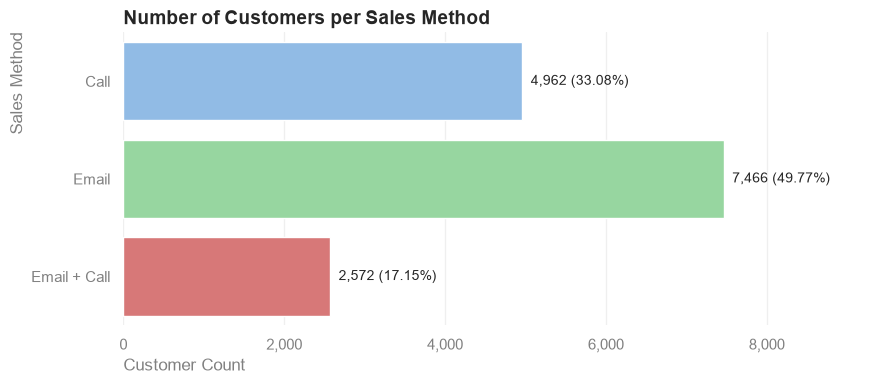

In [9]:
# Apply a consistent style and method order across comparison charts.
sns.set_theme(style="whitegrid")


# Select by method name so bar labels follow the plotted order.
customer_counts = method_statistics["Customer Count"]
customer_percentages = method_statistics["Customer Share Percentage (%)"]

figure, axis = plt.subplots(figsize=(9, 4))

# Each row already contains a customer count; no error bars are needed.
sns.barplot(
	data=sales_method_summary,
	x="Customer Count",
	y="sales_method",
	order=sales_method_order,
	hue="sales_method",
	hue_order=sales_method_order,
	palette=sales_method_colours,
	dodge=False,
	legend=False,
	errorbar=None,
	ax=axis,
)

# Show absolute counts and each method's share of all customer records.
for method_position, sales_method in enumerate(sales_method_order):
	customer_count = customer_counts.loc[sales_method]
	customer_percentage = customer_percentages.loc[sales_method]
	axis.annotate(
		f"{customer_count:,.0f} ({customer_percentage:.2f}%)",
		xy=(customer_count, method_position),
		xytext=(6, 0),
		textcoords="offset points",
		va="center",
		fontsize=10,
	)

axis.set_title(
	"Number of Customers per Sales Method",
	loc="left",
	fontweight="bold",
	fontsize=14,
)

# Start at zero and reserve space for labels beyond the longest bar.
axis.set_xlim(0, customer_counts.max() * 1.25)
axis.xaxis.set_major_locator(MaxNLocator(nbins=6, integer=True))
axis.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
axis.xaxis.set_tick_params(labelcolor="grey")
axis.yaxis.set_tick_params(labelcolor="grey")
axis.set_xlabel("Customer Count", loc="left", color="grey")
axis.set_ylabel("Sales Method", loc="top", color="grey")

# Vertical gridlines help compare bar lengths; horizontal lines add clutter.
axis.set_axisbelow(True)
axis.grid(axis="x", alpha=0.3)
axis.grid(axis="y", visible=False)
sns.despine(ax=axis, left=True, bottom=True)

figure.tight_layout()

figure.savefig(
	f"{figures_path}/Figure 01 Number of Customers per Sales Method.png",
	dpi=300,
	bbox_inches="tight",
)
plt.show()
plt.close(figure)

### Missing revenue by sales method

**Figure 2** `Missing Revenue by Sales Method` compares missing-revenue percentages using all customers within each method as the denominator. Missing revenue affects 181 Call customers (3.65%), 544 Email customers (7.29%), and 349 Email + Call customers (13.57%).

Unequal completeness matters when comparing recorded totals and distributions. The chart identifies where source-data reconciliation is most needed; it does not establish why revenue is missing.

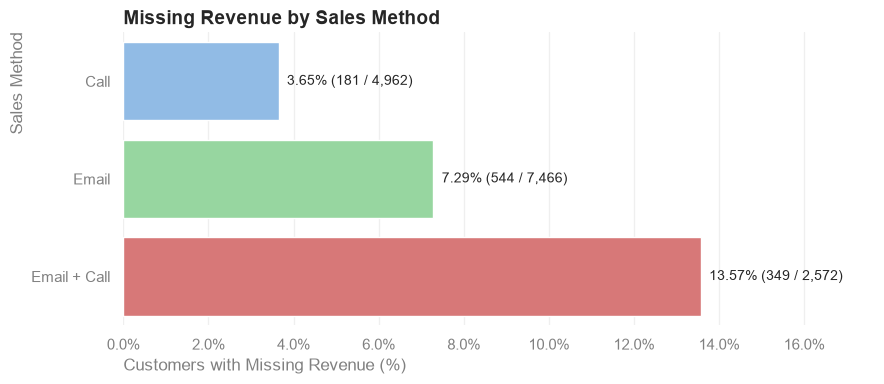

In [10]:
# Reuse the method summary; missingness still refers to source revenue.
missing_revenue_summary = method_statistics[
	["Customer Count", "Recorded Revenue Count",
	 "Missing Revenue Percentage (%)"]
].rename(columns={
	"Customer Count": "customer_count",
	"Recorded Revenue Count": "recorded_revenue_count",
	"Missing Revenue Percentage (%)": "missing_revenue_percentage",
}).copy()
missing_revenue_summary["missing_revenue_count"] = (
	missing_revenue_summary["customer_count"]
	- missing_revenue_summary["recorded_revenue_count"]
)

figure, axis = plt.subplots(figsize=(9, 4))

# Plot pre-calculated percentages directly, without statistical error bars.
sns.barplot(
	data=missing_revenue_summary.reset_index(),
	x="missing_revenue_percentage",
	y="sales_method",
	order=sales_method_order,
	hue="sales_method",
	hue_order=sales_method_order,
	palette=sales_method_colours,
	dodge=False,
	legend=False,
	errorbar=None,
	ax=axis,
)

# Label each method with its missing percentage and record counts.
for method_position, sales_method in enumerate(sales_method_order):
	method_summary = missing_revenue_summary.loc[sales_method]

	axis.annotate(
		f"{method_summary['missing_revenue_percentage']:.2f}% "
		f"({method_summary['missing_revenue_count']:,.0f} / "
		f"{method_summary['customer_count']:,.0f})",
		xy=(method_summary["missing_revenue_percentage"], method_position),
		xytext=(6, 0),
		textcoords="offset points",
		va="center",
		fontsize=10,
	)

axis.set_title(
	"Missing Revenue by Sales Method",
	loc="left",
	fontweight="bold",
	fontsize=14,
)
axis.set_xlabel("Customers with Missing Revenue (%)", color="grey", loc="left")
axis.set_ylabel("Sales Method", color="grey", loc="top")

# Percentages are stored on a 0–100 scale; allow room for count labels.
maximum_percentage = missing_revenue_summary[
	"missing_revenue_percentage"
].max()
axis.set_xlim(0, min(100, max(5, maximum_percentage * 1.3)))
axis.xaxis.set_major_formatter(PercentFormatter(xmax=100))

axis.tick_params(axis="both", labelcolor="grey")
axis.set_axisbelow(True)
axis.grid(axis="x", alpha=0.3)
axis.grid(axis="y", visible=False)
sns.despine(ax=axis, left=True, bottom=True)

figure.tight_layout()

figure.savefig(
	f"{figures_path}/Figure 02 Missing Revenue by Sales Method.png",
	dpi=300,
	bbox_inches="tight",
)
plt.show()
plt.close(figure)

### Distribution of recorded revenue

**Figure 3** `Distribution of Recorded Customer Revenue by Sales Method` separates the recorded-revenue distributions by sales method. Common Freedman–Diaconis bin edges and shared axes support comparison. Each panel shows percentages of customers with recorded revenue within that method, so differences in sample size do not determine the heights.

The panels use 4,781 Call, 6,922 Email, and 2,223 Email + Call records. They show Call revenues concentrated at lower values, Email in the middle, and Email + Call at higher values. The histogram uses no smoothing curve. These distributions describe the available customer revenues; they do not establish normality or explain the causes of differences.

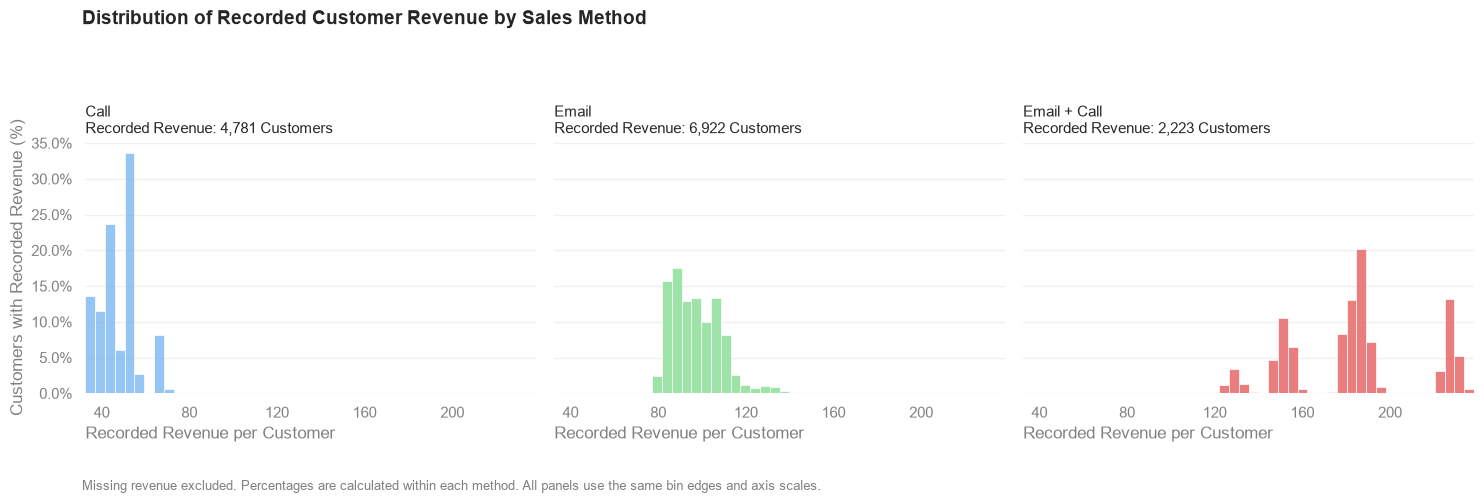

In [11]:
# Exclude missing revenue from distributions; do not plot imputed values.

# Calculate shared Freedman–Diaconis bin edges from all recorded revenues.
# Identical intervals allow direct comparisons between method distributions.
revenue_bin_edges = np.histogram_bin_edges(
	observed_sales["revenue"],
	bins="fd",
)

figure, axes = plt.subplots(
	nrows=1,
	ncols=3,
	figsize=(15, 5),
	sharex=True,
	sharey=True,
)

for axis, sales_method in zip(axes, sales_method_order):
	method_revenue = observed_sales.loc[
		observed_sales["sales_method"] == sales_method
	]

	# Percentages make distribution shapes comparable despite unequal samples.
	sns.histplot(
		data=method_revenue,
		x="revenue",
		bins=revenue_bin_edges,
		stat="percent",
		color=sales_method_colours[sales_method],
		edgecolor="white",
		linewidth=0.5,
		alpha=0.85,
		ax=axis,
	)

	axis.set_title(
		f"{sales_method}\nRecorded Revenue: {len(method_revenue):,} Customers",
		loc="left",
		fontsize=11,
	)
	axis.set_xlabel("Recorded Revenue per Customer", color="grey", loc="left")
	axis.set_ylabel("Customers with Recorded Revenue (%)", color="grey")

	axis.set_xlim(revenue_bin_edges[0], revenue_bin_edges[-1])
	axis.set_ylim(bottom=0)
	axis.xaxis.set_major_locator(MaxNLocator(nbins=6))
	axis.yaxis.set_major_formatter(PercentFormatter(xmax=100))
	axis.tick_params(axis="both", labelcolor="grey")

	axis.set_axisbelow(True)
	axis.grid(axis="y", alpha=0.3)
	axis.grid(axis="x", visible=False)
	sns.despine(ax=axis, left=True, bottom=True)

figure.suptitle(
	"Distribution of Recorded Customer Revenue by Sales Method",
	x=0.06,
	ha="left",
	fontweight="bold",
	fontsize=14,
)
figure.text(
	0.06,
	0.02,
	"Missing revenue excluded. Percentages are calculated within each method. "
	"All panels use the same bin edges and axis scales.",
	fontsize=9,
	color="grey",
)
figure.tight_layout(rect=(0, 0.08, 1, 0.90))

figure.savefig(
	f"{figures_path}/Figure 03 Distribution of Recorded Customer Revenue by Sales Method.png",
	dpi=300,
	bbox_inches="tight",
)
plt.show()
plt.close(figure)

### Comparing revenue distributions and central values

The observed means are 47.60 for Call, 97.13 for Email, and 183.65 for Email + Call. Corresponding medians are 49.07, 95.58, and 184.74. Email + Call's mean is 89.08% higher than Email's and 285.84% higher than Call's among customers with recorded revenue.

Across the full campaign, observed STDs are 8.61, 11.21, and 29.08, respectively. Email + Call has the greatest overall absolute spread, but these pooled results include differences between weeks as well as variation within weeks.

**Figure 4** `Distribution of Recorded Customer Revenue by Sales Method` displays the middle 50% of recorded revenues as boxes, with a median line and a plus marker for the mean. Whiskers extend to observations within 1.5 interquartile ranges of the box boundaries; points beyond them are potential outliers, not automatically errors.

The boxes are descriptive and have no confidence notches. A target population and sampling design have not been established, so this chart does not make a population-median significance claim. Similar means and medians do not prove symmetry. Missingness and customer selection can affect the comparison, and none of these differences establishes a causal sales-method effect.

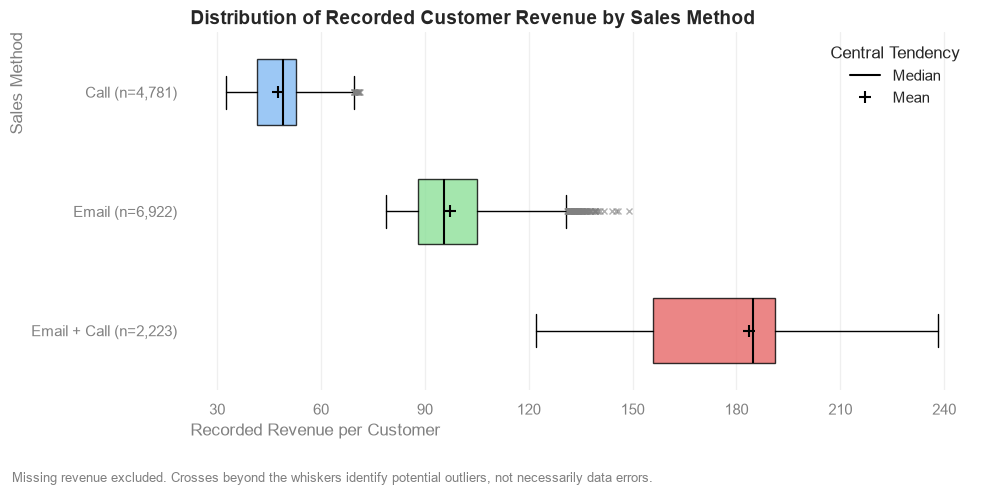

In [12]:
# Exclude missing revenue; estimated amounts do not represent observed
# variation.

recorded_customer_counts = method_statistics["Recorded Revenue Count"]

figure, axis = plt.subplots(figsize=(10, 5))

# Boxes show the middle 50% of recorded revenues.
# Whiskers extend to observations within 1.5 IQR of the box boundaries.
# Matplotlib's orientation API avoids the Seaborn dependency warning.
# Notches are omitted because the analysis is descriptive.
boxplot_artists = axis.boxplot(
	[
		observed_sales.loc[
			observed_sales["sales_method"].eq(sales_method), "revenue"
		].to_numpy()
		for sales_method in sales_method_order
	],
	positions=range(len(sales_method_order)),
	orientation="horizontal",
	patch_artist=True,
	notch=False,
	widths=0.55,
	whis=1.5,
	showmeans=True,
	meanprops={
		"marker": "+", "markeredgecolor": "black",
		"markersize": 9, "markeredgewidth": 1.5,
	},
	medianprops={"color": "black", "linewidth": 1.5},
	flierprops={
		"marker": "x", "markeredgecolor": "grey",
		"markersize": 4, "alpha": 0.6,
	},
)
for box_artist, sales_method in zip(
	boxplot_artists["boxes"], sales_method_order
):
	box_artist.set_facecolor(sales_method_colours[sales_method])
	box_artist.set_alpha(0.8)
axis.invert_yaxis()

# Sample sizes refer to recorded revenues, not all customer records.
axis.set_yticks(
	range(len(sales_method_order)),
	labels=[
		f"{sales_method} (n={recorded_customer_counts.loc[sales_method]:,})"
		for sales_method in sales_method_order
	],
)

axis.set_title(
	"Distribution of Recorded Customer Revenue by Sales Method",
	loc="left",
	fontweight="bold",
	fontsize=14,
)
axis.set_xlabel("Recorded Revenue per Customer", color="grey", loc="left")
axis.set_ylabel("Sales Method", color="grey", loc="top")

# Use data-driven limits with padding so extreme observations remain visible.
axis.margins(x=0.05)
axis.xaxis.set_major_locator(MaxNLocator(nbins=8))
axis.tick_params(axis="both", labelcolor="grey")
axis.set_axisbelow(True)
axis.grid(axis="x", alpha=0.3)
axis.grid(axis="y", visible=False)
sns.despine(ax=axis, left=True, bottom=True)

# Explain the two central-tendency markers independently of method colours.
axis.legend(
	title="Central Tendency",
	handles=[
		Line2D(
			[0], [0],
			color="black",
			linewidth=1.5,
			label="Median",
		),
		Line2D(
			[0], [0],
			color="black",
			marker="+",
			linestyle="None",
			markersize=9,
			markeredgewidth=1.5,
			label="Mean",
		),
	],
	loc="upper right",
	frameon=False,
)

figure.text(
	0.02,
	0.02,
	"Missing revenue excluded. Crosses beyond the whiskers identify potential "
	"outliers, not necessarily data errors.",
	fontsize=9,
	color="grey",
)
figure.tight_layout(rect=(0, 0.07, 1, 1))

figure.savefig(
	f"{figures_path}/Figure 04 Distribution of Recorded Customer Revenue by Sales Method.png",
	dpi=300,
	bbox_inches="tight",
)
plt.show()
plt.close(figure)

### Revenue and quantity sold

**Figure 5** `Recorded Revenue Against Quantity Sold` plots recorded customer revenue against quantity sold, coloured by sales method. Transparency partly reveals overlap, but dense or identical points do not show exact customer counts. The accompanying quantity summary reports those counts explicitly. The chart examines the relationship underpinning the estimation groups: revenue increases with quantity, while the methods occupy different revenue ranges at comparable quantities.

The association supports considering both quantity and method when estimating revenue, but does not identify the underlying pricing, discount, or product-mix mechanism. Imputed amounts are excluded.

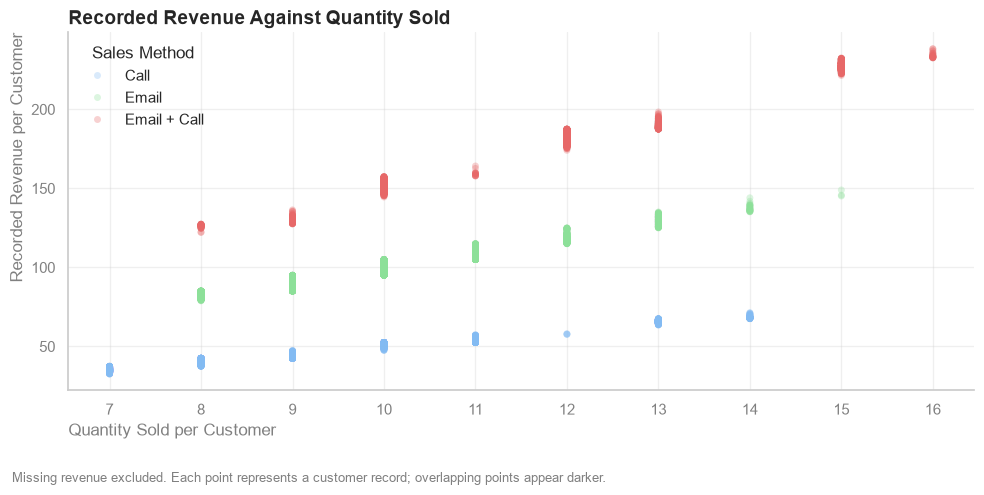

In [13]:
# Scatterplot of recorded revenue against quantity sold, with transparency
# partially revealing overlapping points.

figure, axis = plt.subplots(figsize=(10, 5))

# Keep quantities at their actual values; transparency partly reveals
# overlapping points.
sns.scatterplot(
	data=observed_sales,
	x="nb_sold",
	y="revenue",
	hue="sales_method",
	hue_order=sales_method_order,
	palette=sales_method_colours,
	alpha=0.3,
	s=25,
	linewidth=0,
	ax=axis,
)

axis.set_title(
	"Recorded Revenue Against Quantity Sold",
	loc="left",
	fontweight="bold",
	fontsize=14,
)
axis.set_xlabel("Quantity Sold per Customer", color="grey", loc="left")
axis.set_ylabel("Recorded Revenue per Customer", color="grey", loc="top")

axis.xaxis.set_major_locator(MaxNLocator(integer=True))
axis.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
axis.tick_params(axis="both", labelcolor="grey")
axis.margins(x=0.05, y=0.05)
axis.set_axisbelow(True)
axis.grid(alpha=0.3)
axis.legend(title="Sales Method", frameon=False)
sns.despine(ax=axis)

figure.text(
	0.02,
	0.02,
	"Missing revenue excluded. Each point represents a customer record; "
	"overlapping points appear darker.",
	fontsize=9,
	color="grey",
)
figure.tight_layout(rect=(0, 0.07, 1, 1))

figure.savefig(
	f"{figures_path}/Figure 05 Recorded Revenue Against Quantity Sold.png",
	dpi=300,
	bbox_inches="tight",
)
plt.show()
plt.close(figure)

### Quantity sold and supporting counts

Customer volume and physical sales volume have different units. The following summary reports items sold and items per customer for all records, including missing revenue. The second table reports recorded-revenue support by method and quantity, making counts explicit where the scatterplot overlaps.

Neither table establishes conversion, unit profitability, a pricing schedule, or the effect of the sales method.

In [14]:
# Count items separately from customer records.
quantity_summary = sales_data.groupby(
	"sales_method", observed=True
).agg(
	total_items_sold=("nb_sold", "sum"),
	mean_items_per_customer=("nb_sold", "mean"),
).reindex(sales_method_order)
quantity_summary.insert(0, "customer_count", customer_counts)
quantity_support = observed_sales.groupby(
	["sales_method", "nb_sold"], observed=True
).agg(
	recorded_customer_count=("revenue", "size"),
	observed_mean_revenue=("revenue", "mean"),
	minimum_recorded_revenue=("revenue", "min"),
	maximum_recorded_revenue=("revenue", "max"),
)
display(quantity_summary.round(2))
display(quantity_support.round(2))
quantity_summary.to_csv(tables_path / "Table 13 Quantity Summary.csv")
quantity_support.to_csv(tables_path / "Table 14 Quantity Support.csv")

,customer_count,total_items_sold,mean_items_per_customer
sales_method,,,
Call,4962,47187,9.51
Email,7466,72639,9.73
Email + Call,2572,31444,12.23


recorded_customer_count  observed_mean_revenue  \
sales_method nb_sold                                                   
Call         7                            681                  35.09   
             8                            858                  41.04   
             9                            832                  43.87   
             10                          1125                  51.18   
             11                           854                  53.73   
             12                             4                  57.78   
             13                           365                  65.75   
             14                            62                  68.62   
Email        8                            934                  83.06   
             9                           2399                  89.60   
             10                          1820                  99.76   
             11                          1406                 108.72   
             12                           182                 118.64   
             13                           147                 129.70   
             14                            31                 137.67   
             15                             3                 146.61   
Email + Call 8                             46                 126.08   
             9                             85                 130.42   
             10                           479                 151.49   
             11                            16                 159.42   
             12                           775                 182.84   
             13                           334                 189.83   
             15                           458                 227.35   
             16                            30                 234.14   

                      minimum_recorded_revenue  maximum_recorded_revenue  
sales_method nb_sold                                                      
Call         7                           32.54                     37.48  
             8                           37.50                     42.49  
             9                           42.51                     47.50  
             10                          47.50                     52.50  
             11                          52.51                     57.47  
             12                          57.56                     58.01  
             13                          63.54                     67.50  
             14                          67.52                     71.36  
Email        8                           78.83                     85.00  
             9                           85.00                     95.00  
             10                          95.00                    104.99  
             11                         105.01                    114.98  
             12                         115.00                    124.95  
             13                         125.04                    134.97  
             14                         135.10                    144.01  
             15                         145.15                    148.97  
Email + Call 8                          122.11                    127.37  
             9                          127.55                    136.36  
             10                         144.51                    157.39  
             11                         157.77                    164.14  
             12                         174.07                    187.50  
             13                         187.50                    198.32  
             15                         221.41                    232.47  
             16                         232.52                    238.32

### Recorded and estimated campaign totals

**Figure 6** `Recorded and Estimated Revenue Totals by Sales Method` compares each method's recorded revenue with its total including estimated missing amounts. Email has the largest total on both bases, followed by Email + Call and Call.

The estimated totals are 725,575.35, 473,862.46, and 236,396.51, respectively. The difference between paired bars is the imputed addition; the bars must not be added together. Aggregate totals depend on customer volume as well as revenue per customer and do not measure efficiency or profitability.

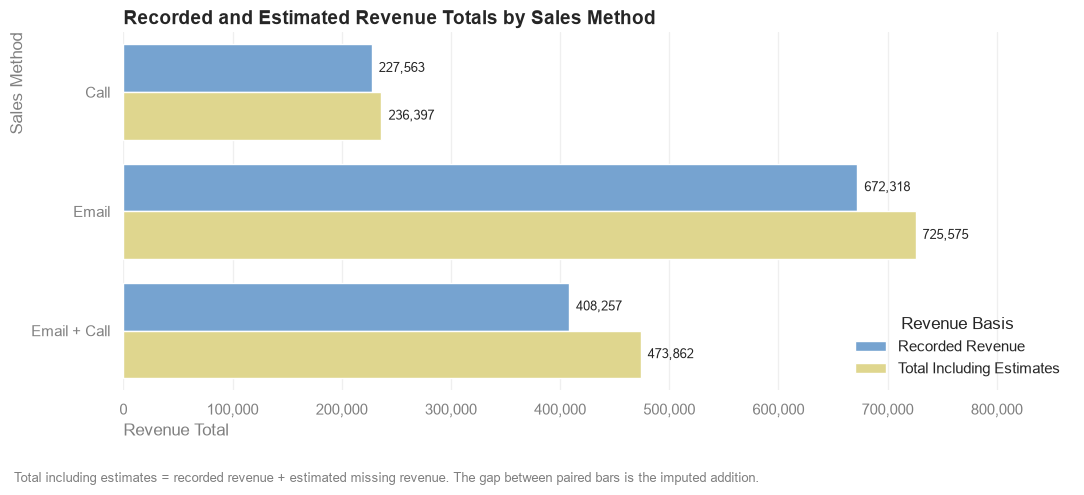

In [15]:
# Summarise recorded and estimated revenue totals by sales method.
revenue_total_order = [
	"Recorded Revenue",
	"Total Including Estimates",
]
revenue_total_colours = {
	"Recorded Revenue": "#67A3DF",
	"Total Including Estimates": "#ECE081",
}

# Recorded totals exclude missing amounts; estimated totals include
# replacements.
revenue_totals = method_statistics[
	["Recorded Revenue Total", "Estimated Revenue Total"]
].rename(columns={
	"Recorded Revenue Total": "Recorded Revenue",
	"Estimated Revenue Total": "Total Including Estimates",
}).reset_index()

revenue_totals_long = revenue_totals.melt(
	id_vars="sales_method",
	value_vars=revenue_total_order,
	var_name="revenue_basis",
	value_name="revenue_total",
)

figure, axis = plt.subplots(figsize=(11, 5))

# Paired bars compare totals directly without stacking overlapping amounts.
sns.barplot(
	data=revenue_totals_long,
	x="revenue_total",
	y="sales_method",
	order=sales_method_order,
	hue="revenue_basis",
	hue_order=revenue_total_order,
	palette=revenue_total_colours,
	errorbar=None,
	ax=axis,
)

for bar_container in axis.containers:
	axis.bar_label(
		bar_container,
		labels=[
			f"{bar.get_width():,.0f}"
			for bar in bar_container
		],
		padding=5,
		fontsize=9,
	)

axis.set_title(
	"Recorded and Estimated Revenue Totals by Sales Method",
	loc="left",
	fontweight="bold",
	fontsize=14,
)
axis.set_xlabel("Revenue Total", color="grey", loc="left")
axis.set_ylabel("Sales Method", color="grey", loc="top")

# Reserve space for labels and use a zero baseline for comparing bar lengths.
axis.set_xlim(0, revenue_totals_long["revenue_total"].max() * 1.20)
axis.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
axis.tick_params(axis="both", labelcolor="grey")
axis.set_axisbelow(True)
axis.grid(axis="x", alpha=0.3)
axis.grid(axis="y", visible=False)
axis.legend(title="Revenue Basis", loc="lower right", frameon=False)
sns.despine(ax=axis, left=True, bottom=True)

figure.text(
	0.02,
	0.02,
	"Total including estimates = recorded revenue + estimated missing revenue. "
	"The gap between paired bars is the imputed addition.",
	fontsize=9,
	color="grey",
)
figure.tight_layout(rect=(0, 0.07, 1, 1))

figure.savefig(
	f"{figures_path}/Figure 06 Recorded and Estimated Revenue Totals by Sales Method.png",
	dpi=300,
	bbox_inches="tight",
)
plt.show()
plt.close(figure)

### Weekly customer volume and revenue completeness

Weekly customer volumes, method composition, and revenue completeness are examined before revenue trends. The records contain unique customer identifiers, so each week represents a different group of customers rather than repeated observations of the same people.

The following table reports customer counts, recorded-revenue counts, missingness, and method shares within each week. Checks reconcile the counts with the source data. **Figure 7** `Weekly Customer Counts by Sales Method` then plots customer volume by method.

The method mix changes substantially: Email represents 75.65% of records in week 1 and 16.04% in week 6, while Email + Call rises from 3.98% to 47.48%. Overall customer count declines from 3,721 to 1,228. These changes provide essential context for interpreting aggregate spending and revenue.

In [16]:
# Summarise weekly customer counts and missingness by sales method.

# Reject invalid grouping values before reindexing can discard their groups.
if (
	sales_data["week"].isna().any()
	or not sales_data["week"].isin(expected_weeks).all()
):
	raise ValueError(
		"Weekly analysis requires campaign weeks 1–6 with no missing values."
	)

if (
	sales_data["sales_method"].isna().any()
	or not sales_data["sales_method"].isin(sales_method_order).all()
):
	raise ValueError(
		"Weekly analysis contains missing or unexpected sales methods."
	)

weekly_sales_summary = sales_data.groupby(
	["week", "sales_method"],
	observed=True,
).agg(
	customer_count=("customer_id", "size"),
	recorded_revenue_count=("revenue", "count"),
)

# Include every method–week combination, even when no customers were recorded.
expected_week_method_index = pd.MultiIndex.from_product(
	[expected_weeks, sales_method_order],
	names=["week", "sales_method"],
)
weekly_sales_summary = weekly_sales_summary.reindex(
	expected_week_method_index,
	fill_value=0,
)

weekly_sales_summary["missing_revenue_count"] = (
	weekly_sales_summary["customer_count"]
	- weekly_sales_summary["recorded_revenue_count"]
)

# Missingness uses the group's customers as its denominator.
# A group with no customers has an undefined rate, rather than 0% missingness.
weekly_sales_summary["missing_revenue_percentage"] = (
	weekly_sales_summary["missing_revenue_count"]
	/ weekly_sales_summary["customer_count"].replace(0, np.nan)
	* 100
)

# Method share uses all customer records in that week as its denominator.
weekly_customer_totals = weekly_sales_summary.groupby(
	level="week"
)["customer_count"].transform("sum")

weekly_sales_summary["weekly_customer_share_percentage"] = (
	weekly_sales_summary["customer_count"]
	/ weekly_customer_totals
	* 100
)

# Reconcile each week's counts against the original records.
source_weekly_customer_counts = (
	sales_data.groupby("week", observed=True)
	.size()
	.reindex(expected_weeks, fill_value=0)
)
summary_weekly_customer_counts = (
	weekly_sales_summary.groupby(level="week")["customer_count"]
	.sum()
	.reindex(expected_weeks)
)

if not np.array_equal(
	summary_weekly_customer_counts.to_numpy(),
	source_weekly_customer_counts.to_numpy(),
):
	raise ValueError("Weekly customer counts do not reconcile with sales_data.")

if weekly_sales_summary["recorded_revenue_count"].sum() != (
	sales_data["revenue"].notna().sum()
):
	raise ValueError("Recorded-revenue counts do not reconcile.")

if weekly_sales_summary["missing_revenue_count"].sum() != (
	sales_data["revenue"].isna().sum()
):
	raise ValueError("Missing-revenue counts do not reconcile.")

weekly_method_share_totals = weekly_sales_summary.groupby(
	level="week"
)["weekly_customer_share_percentage"].sum()

if not np.allclose(
	weekly_method_share_totals, 100,
	rtol=0, atol=percentage_reconciliation_tolerance,
):
	raise ValueError("Sales-method shares must total 100% within each week.")


# Keep full precision in the summary; round only the displayed copy.
weekly_sales_summary = weekly_sales_summary.reset_index()

print("Weekly customer volumes and revenue completeness:")
display(weekly_sales_summary.round(2).rename(columns={
	"customer_count": "Customer Count",
	"recorded_revenue_count": "Recorded Revenue Count",
	"missing_revenue_count": "Missing Revenue Count",
	"missing_revenue_percentage": "Missing Revenue Percentage (%)",
	"weekly_customer_share_percentage": "Weekly Customer Share Percentage (%)",
	"week": "Week",
	"sales_method": "Sales Method",
}))

Weekly customer volumes and revenue completeness:


,Week,Sales Method,Customer Count,Recorded Revenue Count,Missing Revenue Count,Missing Revenue Percentage (%),Weekly Customer Share Percentage (%)
0,1,Call,758,740,18,2.37,20.37
1,1,Email,2815,2626,189,6.71,75.65
2,1,Email + Call,148,131,17,11.49,3.98
3,2,Call,805,775,30,3.73,32.32
4,2,Email,1486,1377,109,7.34,59.65
5,2,Email + Call,200,171,29,14.50,8.03
6,3,Call,902,868,34,3.77,37.41
7,3,Email,1150,1065,85,7.39,47.70
8,3,Email + Call,359,324,35,9.75,14.89
9,4,Call,1005,964,41,4.08,39.03


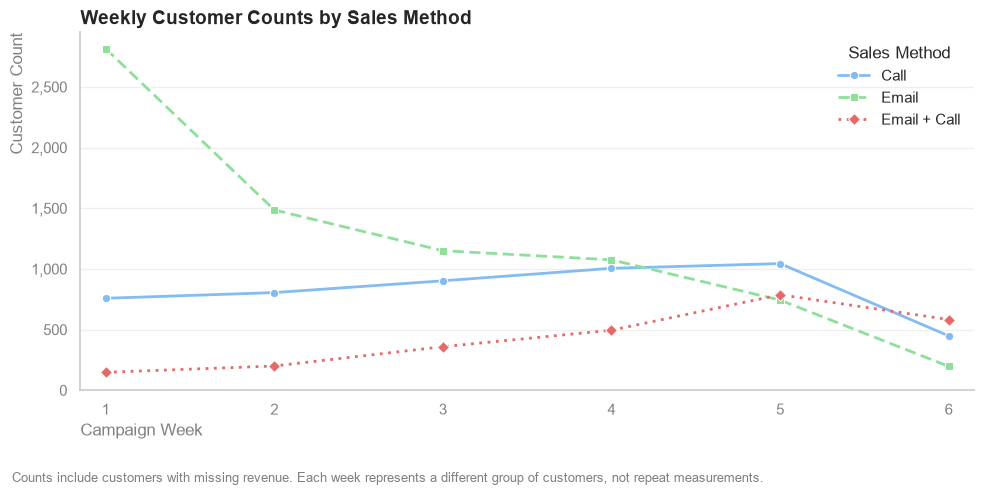

In [17]:
# Plot weekly customer counts by sales method, including weeks with no
# customers.
figure, axis = plt.subplots(figsize=(10, 5))

sns.lineplot(
	data=weekly_sales_summary,
	x="week",
	y="customer_count",
	hue="sales_method",
	hue_order=sales_method_order,
	palette=sales_method_colours,
	style="sales_method",
	style_order=sales_method_order,
	markers=sales_method_markers,
	dashes=sales_method_dashes,
	linewidth=2,
	estimator=None,
	errorbar=None,
	ax=axis,
)

axis.set_title(
	"Weekly Customer Counts by Sales Method",
	loc="left",
	fontweight="bold",
	fontsize=14,
)
axis.set_xlabel("Campaign Week", color="grey", loc="left")
axis.set_ylabel("Customer Count", color="grey", loc="top")

axis.set_xticks(expected_weeks)
axis.set_ylim(bottom=0)
axis.margins(x=0.03)
axis.yaxis.set_major_locator(MaxNLocator(nbins=6, integer=True))
axis.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
axis.tick_params(axis="both", labelcolor="grey")

axis.set_axisbelow(True)
axis.grid(axis="y", alpha=0.3)
axis.grid(axis="x", visible=False)
axis.legend(title="Sales Method", frameon=False)
sns.despine(ax=axis)

figure.text(
	0.02,
	0.02,
	"Counts include customers with missing revenue. Each week represents "
	"a different group of customers, not repeat measurements.",
	fontsize=9,
	color="grey",
)
figure.tight_layout(rect=(0, 0.07, 1, 1))

figure.savefig(
	f"{figures_path}/Figure 07 Weekly Customer Counts by Sales Method.png",
	dpi=300,
	bbox_inches="tight",
)
plt.show()
plt.close(figure)

### Weekly observed mean, median, and standard deviation

The following cell calculates weekly means, medians, and sample STDs from recorded revenue, retaining sample counts and missingness for context. **Figure 8** `Weekly Mean Recorded Revenue by Sales Method` then plots the weekly means by method.

Email + Call has the highest mean in each week, followed by Email and Call. All three observed means decrease between weeks 2 and 3, so growth is not uninterrupted. Email has the largest within-week STD in every week, despite Email + Call having the greatest pooled campaign STD.

Within-week STD describes customer variation; it is not a confidence interval or a measure of representativeness. Changing customer composition and missingness limit explanations of the weekly differences.

In [18]:
# Calculate distribution statistics using recorded revenue only.
# Pandas STD uses ddof=1; it is undefined with fewer than two observations.
weekly_observed_revenue = sales_data.groupby(
	["week", "sales_method"],
	observed=True,
).agg(
	observed_mean_revenue=("revenue", "mean"),
	observed_median_revenue=("revenue", "median"),
	observed_revenue_std=("revenue", "std"),
).reset_index()

# Refresh these columns safely when the cell is rerun.
observed_statistic_columns = [
	"observed_mean_revenue",
	"observed_median_revenue",
	"observed_revenue_std",
]
weekly_sales_summary = (
	weekly_sales_summary.drop(
		columns=observed_statistic_columns,
		errors="ignore",
	)
	.merge(
		weekly_observed_revenue,
		on=["week", "sales_method"],
		how="left",
		validate="one_to_one",
	)
)

# Absent groups retain undefined statistics rather than artificial zeros.
if weekly_sales_summary.loc[
	weekly_sales_summary["recorded_revenue_count"].eq(0),
	observed_statistic_columns,
].notna().any().any():
	raise ValueError("Groups without recorded revenue must have undefined statistics.")

if weekly_sales_summary.loc[
	weekly_sales_summary["recorded_revenue_count"].lt(2),
	"observed_revenue_std",
].notna().any():
	raise ValueError("Sample STD requires at least two recorded revenues.")

# Reconcile weekly means with the overall observed mean using recorded counts.
weighted_observed_mean = (
	(
		weekly_sales_summary["observed_mean_revenue"]
		* weekly_sales_summary["recorded_revenue_count"]
	).sum()
	/ weekly_sales_summary["recorded_revenue_count"].sum()
)

if not np.isclose(
	weighted_observed_mean,
	sales_data["revenue"].mean(),
	equal_nan=True,
	rtol=0, atol=mean_reconciliation_tolerance,
):
	raise ValueError("Weekly observed means do not reconcile with recorded revenue.")

print("Weekly observed revenue statistics:")
display(
	weekly_sales_summary[
		[
			"week",
			"sales_method",
			"customer_count",
			"recorded_revenue_count",
			"missing_revenue_percentage",
			"observed_mean_revenue",
			"observed_median_revenue",
			"observed_revenue_std",
		]
	].round(2).rename(columns={
		"week": "Week",
		"sales_method": "Sales Method",
		"customer_count": "Customer Count",
		"recorded_revenue_count": "Recorded Revenue Count",
		"missing_revenue_percentage": "Missing Revenue Percentage (%)",
		"observed_mean_revenue": "Observed Mean Revenue",
		"observed_median_revenue": "Observed Median Revenue",
		"observed_revenue_std": "Observed Revenue Std Dev",
		}
		)
		)

Weekly observed revenue statistics:


,Week,Sales Method,Customer Count,Recorded Revenue Count,Missing Revenue Percentage (%),Observed Mean Revenue,Observed Median Revenue,Observed Revenue Std Dev
0,1,Call,758,740,2.37,35.35,35.20,1.36
1,1,Email,2815,2626,6.71,87.50,86.54,4.87
2,1,Email + Call,148,131,11.49,128.90,128.72,2.76
3,2,Call,805,775,3.73,43.60,43.46,1.34
4,2,Email,1486,1377,7.34,100.14,99.25,4.74
5,2,Email + Call,200,171,14.50,154.25,154.17,2.67
6,3,Call,902,868,3.77,41.76,41.47,1.47
7,3,Email,1150,1065,7.39,92.76,91.80,4.52
8,3,Email + Call,359,324,9.75,150.42,149.93,2.88
9,4,Call,1005,964,4.08,51.45,51.27,1.34


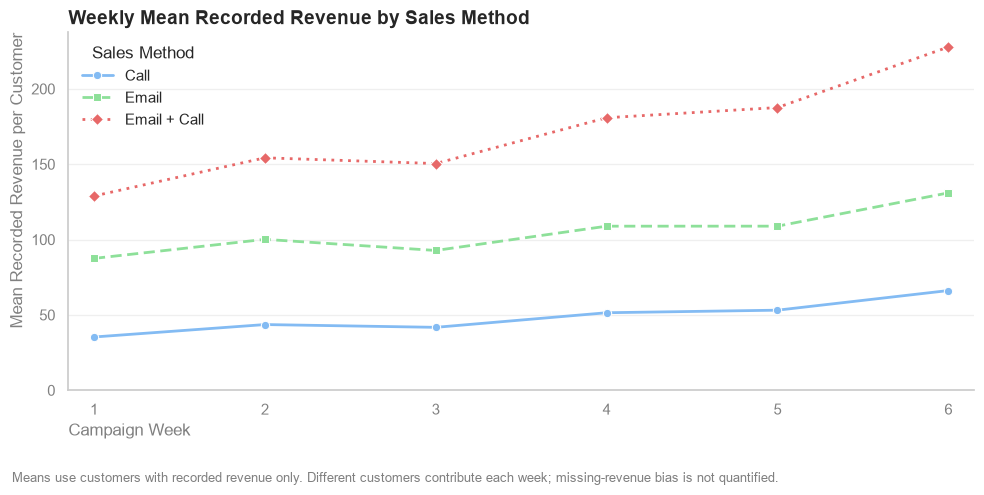

In [19]:
# Plot weekly means to compare methods, ignoring missing revenue.
figure, axis = plt.subplots(figsize=(10, 5))

# Each point is an observed weekly mean, already calculated above.
# STD is reported in the table; it is not a confidence interval for the mean.
sns.lineplot(
	data=weekly_sales_summary,
	x="week",
	y="observed_mean_revenue",
	hue="sales_method",
	hue_order=sales_method_order,
	palette=sales_method_colours,
	style="sales_method",
	style_order=sales_method_order,
	markers=sales_method_markers,
	dashes=sales_method_dashes,
	linewidth=2,
	estimator=None,
	errorbar=None,
	ax=axis,
)

axis.set_title(
	"Weekly Mean Recorded Revenue by Sales Method",
	loc="left",
	fontweight="bold",
	fontsize=14,
)
axis.set_xlabel("Campaign Week", color="grey", loc="left")
axis.set_ylabel("Mean Recorded Revenue per Customer", color="grey", loc="top")

axis.set_xticks(sorted(weekly_sales_summary["week"].unique()))
axis.set_ylim(bottom=0)
axis.margins(x=0.03)
axis.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
axis.tick_params(axis="both", labelcolor="grey")

axis.set_axisbelow(True)
axis.grid(axis="y", alpha=0.3)
axis.grid(axis="x", visible=False)
axis.legend(title="Sales Method", frameon=False)
sns.despine(ax=axis)

figure.text(
	0.02,
	0.02,
	"Means use customers with recorded revenue only. "
	"Different customers contribute each week; missing-revenue bias is not quantified.",
	fontsize=9,
	color="grey",
)
figure.tight_layout(rect=(0, 0.07, 1, 1))

figure.savefig(
	f"{figures_path}/Figure 08 Weekly Mean Recorded Revenue by Sales Method.png",
	dpi=300,
	bbox_inches="tight",
)
plt.show()
plt.close(figure)

### Weekly estimated total revenue

The preceding mean-revenue chart describes spending among customers with recorded revenue. The following table and **Figure 9** `Weekly Estimated Total Revenue by Sales Method` instead examine estimated total revenue, including imputed amounts, by method and week. The table separates recorded revenue from the imputed addition and checks their reconciliation.

Email has the largest estimated total in weeks 1–4; Email + Call has the largest in weeks 5–6. Email + Call's estimated total peaks at 147,644.08 in week 5 before falling to 132,757.42 in week 6, even though its observed mean revenue increases. Customer volume must therefore be considered alongside spending.

The chart does not display uncertainty intervals: the estimation procedure produces point estimates and does not quantify uncertainty in total revenue.

In [20]:
# Separate observed amounts from estimates assigned to missing revenues.
# Zero here represents no contribution to that component, not zero missing
# revenue.
revenue_components = sales_data[
	["week", "sales_method", "estimated_revenue"]
].copy()

revenue_components["recorded_revenue_total"] = (
	sales_data["revenue"].fillna(0)
)
revenue_components["imputed_revenue_addition"] = (
	sales_data["estimated_revenue"].where(
		sales_data["revenue"].isna(),
		0,
	)
)

weekly_revenue_totals = revenue_components.groupby(
	["week", "sales_method"],
	observed=True,
).agg(
	recorded_revenue_total=("recorded_revenue_total", "sum"),
	imputed_revenue_addition=("imputed_revenue_addition", "sum"),
	estimated_revenue_total=("estimated_revenue", "sum"),
).reset_index()

# Refresh total columns safely when this cell is rerun.
revenue_total_columns = [
	"recorded_revenue_total",
	"imputed_revenue_addition",
	"estimated_revenue_total",
]
weekly_sales_summary = (
	weekly_sales_summary.drop(
		columns=revenue_total_columns,
		errors="ignore",
	)
	.merge(
		weekly_revenue_totals,
		on=["week", "sales_method"],
		how="left",
		validate="one_to_one",
	)
)

# Method–week groups with no customer records contribute zero revenue.
empty_customer_groups = weekly_sales_summary["customer_count"].eq(0)
weekly_sales_summary.loc[
	empty_customer_groups,
	revenue_total_columns,
] = 0

if weekly_sales_summary[revenue_total_columns].isna().any().any():
	raise ValueError("Some populated method–week groups have missing totals.")


# Reconcile each group's total and the overall total before plotting.
if not np.allclose(
	weekly_sales_summary["recorded_revenue_total"]
	+ weekly_sales_summary["imputed_revenue_addition"],
	weekly_sales_summary["estimated_revenue_total"],
	rtol=0, atol=revenue_reconciliation_tolerance,
):
	raise ValueError("Recorded revenue plus imputed additions must equal the total.")

if not np.isclose(
	weekly_sales_summary["estimated_revenue_total"].sum(),
	sales_data["estimated_revenue"].sum(),
	rtol=0, atol=revenue_reconciliation_tolerance,
):
	raise ValueError("Weekly estimated totals do not reconcile with sales_data.")

print("Weekly recorded and estimated revenue totals:")
display(
	weekly_sales_summary[
		[
			"week",
			"sales_method",
			"customer_count",
			"missing_revenue_count",
			"recorded_revenue_total",
			"imputed_revenue_addition",
			"estimated_revenue_total",
		]
	].round(2).rename(columns={
		"week": "Week",
		"sales_method": "Sales Method",
		"customer_count": "Customer Count",
		"missing_revenue_count": "Missing Revenue Count",
		"recorded_revenue_total": "Recorded Revenue Total",
		"imputed_revenue_addition": "Imputed Revenue Addition",
		"estimated_revenue_total": "Estimated Revenue Total",
		}
		)
)

Weekly recorded and estimated revenue totals:


,Week,Sales Method,Customer Count,Missing Revenue Count,Recorded Revenue Total,Imputed Revenue Addition,Estimated Revenue Total
0,1,Call,758,18,26159.18,634.90,26794.08
1,1,Email,2815,189,229765.55,16496.43,246261.98
2,1,Email + Call,148,17,16885.33,2195.43,19080.76
3,2,Call,805,30,33792.02,1311.51,35103.53
4,2,Email,1486,109,137891.57,10898.16,148789.73
5,2,Email + Call,200,29,26376.23,4484.38,30860.61
6,3,Call,902,34,36247.27,1413.91,37661.18
7,3,Email,1150,85,98792.14,8022.61,106814.75
8,3,Email + Call,359,35,48737.14,5261.05,53998.19
9,4,Call,1005,41,49593.99,2107.84,51701.83


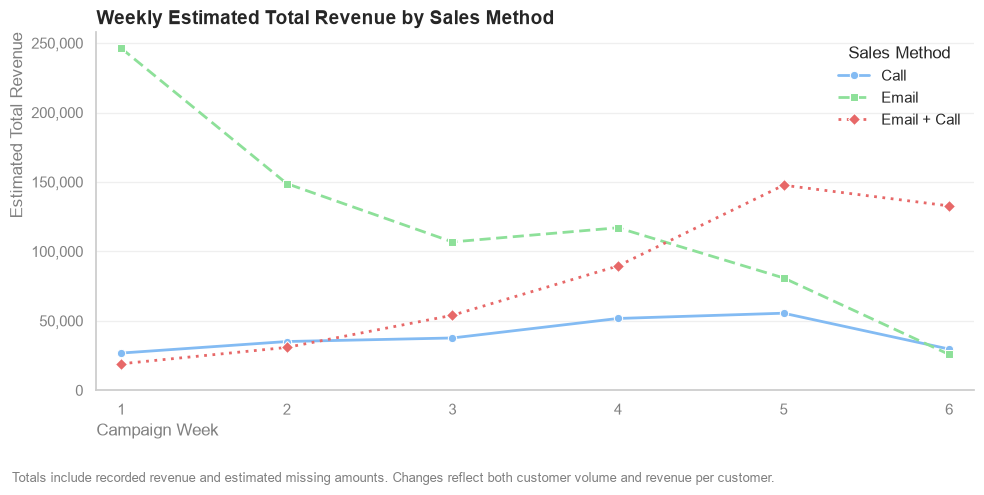

In [21]:
# Plot estimated totals to compare methods, including imputed amounts.
figure, axis = plt.subplots(figsize=(10, 5))

# Each point includes recorded revenue and estimated missing amounts.
# No confidence band is shown: imputation uncertainty has not been quantified.
sns.lineplot(
	data=weekly_sales_summary,
	x="week",
	y="estimated_revenue_total",
	hue="sales_method",
	hue_order=sales_method_order,
	palette=sales_method_colours,
	style="sales_method",
	style_order=sales_method_order,
	markers=sales_method_markers,
	dashes=sales_method_dashes,
	linewidth=2,
	estimator=None,
	errorbar=None,
	ax=axis,
)

axis.set_title(
	"Weekly Estimated Total Revenue by Sales Method",
	loc="left",
	fontweight="bold",
	fontsize=14,
)
axis.set_xlabel("Campaign Week", color="grey", loc="left")
axis.set_ylabel("Estimated Total Revenue", color="grey", loc="top")

axis.set_xticks(sorted(weekly_sales_summary["week"].unique()))
axis.set_ylim(bottom=0)
axis.margins(x=0.03)
axis.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
axis.tick_params(axis="both", labelcolor="grey")

axis.set_axisbelow(True)
axis.grid(axis="y", alpha=0.3)
axis.grid(axis="x", visible=False)
axis.legend(title="Sales Method", frameon=False)
sns.despine(ax=axis)

figure.text(
	0.02,
	0.02,
	"Totals include recorded revenue and estimated missing amounts. "
	"Changes reflect both customer volume and revenue per customer.",
	fontsize=9,
	color="grey",
)
figure.tight_layout(rect=(0, 0.07, 1, 1))

figure.savefig(
	f"{figures_path}/Figure 09 Weekly Estimated Total Revenue by Sales Method.png",
	dpi=300,
	bbox_inches="tight",
)
plt.show()
plt.close(figure)

### Week-over-week growth by sales method

The following calculation compares each week's value with the preceding week within the same method: `(current / previous - 1) × 100`. **Figure 10** `Week-over-Week Revenue Growth by Sales Method` separates growth in observed mean revenue from growth in estimated total revenue.

Week 1 has no preceding campaign observation. A zero or missing previous value also produces an undefined rate rather than zero growth. Rates are calculated before rounding and displayed as percentages.

Between weeks 5 and 6, observed mean revenue rises for all methods, while estimated total revenue falls by 46.58% for Call, 68.11% for Email, and 10.08% for Email + Call. The different directions demonstrate why average spending and total revenue require separate monitoring.

In [22]:
# Calculate week-over-week growth for observed means and estimated totals.
required_growth_columns = [
	"week",
	"sales_method",
	"observed_mean_revenue",
	"estimated_revenue_total",
]
missing_growth_columns = set(required_growth_columns) - set(
	weekly_sales_summary.columns
)

if missing_growth_columns:
	raise ValueError(
		f"Required columns are missing: {sorted(missing_growth_columns)}"
	)

if weekly_sales_summary.duplicated(["week", "sales_method"]).any():
	raise ValueError("Each sales method must have only one row per week.")

if set(weekly_sales_summary["sales_method"]) != set(sales_method_order):
	raise ValueError("Unexpected or missing sales methods in the weekly summary.")

for sales_method in sales_method_order:
	method_weeks = sorted(
		weekly_sales_summary.loc[
			weekly_sales_summary["sales_method"] == sales_method,
			"week",
		].tolist()
	)
	if method_weeks != expected_weeks:
		raise ValueError(
			f"{sales_method} must contain exactly weeks 1–6."
		)


# Calculate from unrounded values in chronological order within each method.
weekly_sales_summary = weekly_sales_summary.sort_values(
	["sales_method", "week"]
).reset_index(drop=True)

growth_columns = {
	"observed_mean_revenue": "observed_mean_wow_growth_fraction",
	"estimated_revenue_total": "estimated_total_wow_growth_fraction",
}

for revenue_column, growth_column in growth_columns.items():
	previous_week_revenue = weekly_sales_summary.groupby(
		"sales_method",
		observed=True,
	)[revenue_column].shift(1)

	# Growth is undefined when the previous week's value is zero or missing.
	# Do not forward-fill unavailable means or replace undefined growth with zero.
	valid_previous_revenue = previous_week_revenue.where(
		previous_week_revenue.notna()
		& previous_week_revenue.ne(0)
	)

	weekly_sales_summary[growth_column] = (
		weekly_sales_summary[revenue_column]
		/ valid_previous_revenue
		- 1
	)

# Restore the week-first table order for reading.
weekly_sales_summary = weekly_sales_summary.sort_values(
	["week", "sales_method"]
).reset_index(drop=True)
weekly_sales_summary.to_csv(
	f"{tables_path}/Table 06 Weekly Sales Summary.csv", index=False
)

# Store growth as fractions; convert only the display copy to percentages.
growth_display = weekly_sales_summary[
	[
		"week",
		"sales_method",
		"observed_mean_revenue",
		"observed_mean_wow_growth_fraction",
		"estimated_revenue_total",
		"estimated_total_wow_growth_fraction",
	]
].copy()

for growth_column in growth_columns.values():
	growth_display[growth_column] = growth_display[growth_column] * 100

growth_display = growth_display.rename(
	columns={
		"observed_mean_wow_growth_fraction": "observed_mean_wow_growth_percentage",
		"estimated_total_wow_growth_fraction": "estimated_total_wow_growth_percentage",
	}
)

print("Weekly revenue levels and week-over-week growth (%):")
display(growth_display.round(2).rename(columns={
	"week": "Week",
	"observed_mean_wow_growth_percentage": "Observed Mean WoW Growth (%)",
	"estimated_total_wow_growth_percentage": "Estimated Total WoW Growth (%)",
	"observed_mean_revenue": "Observed Mean Revenue",
	"estimated_revenue_total": "Estimated Total Revenue",
	"sales_method": "Sales Method",
}))

Weekly revenue levels and week-over-week growth (%):


,Week,Sales Method,Observed Mean Revenue,Observed Mean WoW Growth (%),Estimated Total Revenue,Estimated Total WoW Growth (%)
0,1,Call,35.35,NaN,26794.08,NaN
1,1,Email,87.50,NaN,246261.98,NaN
2,1,Email + Call,128.90,NaN,19080.76,NaN
3,2,Call,43.60,23.34,35103.53,31.01
4,2,Email,100.14,14.45,148789.73,-39.58
5,2,Email + Call,154.25,19.67,30860.61,61.74
6,3,Call,41.76,-4.23,37661.18,7.29
7,3,Email,92.76,-7.37,106814.75,-28.21
8,3,Email + Call,150.42,-2.48,53998.19,74.97
9,4,Call,51.45,23.20,51701.83,37.28


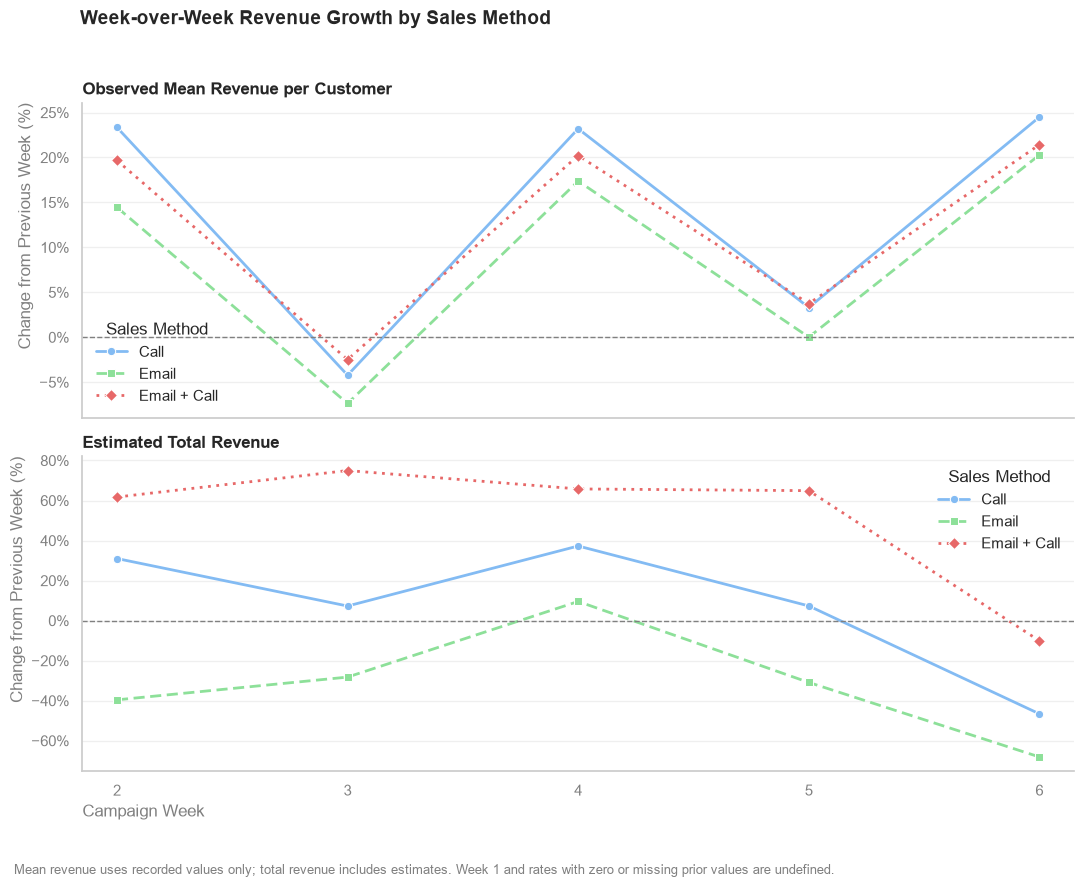

In [23]:
# Use separate panels because spending per customer and total revenue differ.
figure, axes = plt.subplots(
	nrows=2,
	ncols=1,
	figsize=(11, 9),
	sharex=True,
)

growth_panels = [
	(
		"observed_mean_wow_growth_fraction",
		"Observed Mean Revenue per Customer",
	),
	(
		"estimated_total_wow_growth_fraction",
		"Estimated Total Revenue",
	),
]

for axis, (growth_column, panel_title) in zip(axes, growth_panels):
	# Separate line segments at undefined rates so gaps are not bridged.
	growth_plot_data = weekly_sales_summary[
		["week", "sales_method", growth_column]
	].copy()
	growth_plot_data["growth_segment"] = growth_plot_data.groupby(
		"sales_method",
		observed=True,
	)[growth_column].transform(
		lambda growth_values: growth_values.isna().cumsum()
	)

	sns.lineplot(
		data=growth_plot_data,
		x="week",
		y=growth_column,
		hue="sales_method",
		hue_order=sales_method_order,
		palette=sales_method_colours,
		units="growth_segment",
		style="sales_method",
		style_order=sales_method_order,
		markers=sales_method_markers,
		dashes=sales_method_dashes,
		linewidth=2,
		estimator=None,
		errorbar=None,
		ax=axis,
	)

	axis.axhline(
		0,
		color="grey",
		linestyle="--",
		linewidth=1,
	)
	axis.set_title(
		panel_title,
		loc="left",
		fontweight="bold",
		fontsize=12,
	)
	axis.set_xlabel("Campaign Week", color="grey", loc="left")
	axis.set_ylabel("Change from Previous Week (%)", color="grey", loc="top")

	# Stored values are fractions: 0.10 must display as 10%, not 0.10%.
	axis.yaxis.set_major_formatter(
		PercentFormatter(xmax=1, decimals=0)
	)
	axis.set_xticks(expected_weeks[1:])
	axis.set_xlim(1.85, 6.15)
	axis.tick_params(axis="both", labelcolor="grey")
	axis.set_axisbelow(True)
	axis.grid(axis="y", alpha=0.3)
	axis.grid(axis="x", visible=False)
	axis.legend(title="Sales Method", frameon=False)
	sns.despine(ax=axis)

figure.suptitle(
	"Week-over-Week Revenue Growth by Sales Method",
	x=0.08,
	ha="left",
	fontweight="bold",
	fontsize=14,
)
figure.text(
	0.02,
	0.02,
	"Mean revenue uses recorded values only; total revenue includes estimates. "
	"Week 1 and rates with zero or missing prior values are undefined.",
	fontsize=9,
	color="grey",
)
figure.tight_layout(rect=(0, 0.06, 1, 0.96))

figure.savefig(
	f"{figures_path}/Figure 10 Week-over-Week Revenue Growth by Sales Method.png",
	dpi=300,
	bbox_inches="tight",
)
plt.show()
plt.close(figure)

### Change between weeks 1 and 6

The next table compares the campaign endpoints directly. Absolute change is week 6 minus week 1; percentage change divides that difference by the week 1 value. These are changes over five weekly intervals, not average weekly growth rates.

Observed mean revenue increases by 30.82 for Call (87.17%), 43.48 for Email (49.69%), and 98.87 for Email + Call (76.71%). Email + Call has the greatest absolute increase, while Call has the greatest percentage increase. Customer-count and estimated-total changes are reported alongside spending so these measures are not conflated.

In [24]:
# Compare the campaign endpoints, not the minimum and maximum weekly values.
endpoint_metrics = [
	"customer_count",
	"observed_mean_revenue",
	"estimated_revenue_total",
]

required_columns = {"week", "sales_method", *endpoint_metrics}
missing_columns = required_columns - set(weekly_sales_summary.columns)

if missing_columns:
	raise ValueError(
		f"Required columns are missing: {sorted(missing_columns)}"
	)

endpoint_data = weekly_sales_summary.loc[
	weekly_sales_summary["week"].isin([expected_weeks[0], expected_weeks[-1]]),
	["week", "sales_method", *endpoint_metrics],
].copy()

if endpoint_data.duplicated(["week", "sales_method"]).any():
	raise ValueError("Each method must have only one row per endpoint week.")

expected_endpoint_index = pd.MultiIndex.from_product(
	[[expected_weeks[0], expected_weeks[-1]], sales_method_order],
	names=["week", "sales_method"],
)
endpoint_data = endpoint_data.set_index(["week", "sales_method"])

missing_endpoints = expected_endpoint_index.difference(endpoint_data.index)
if len(missing_endpoints) > 0:
	raise ValueError(
		f"Missing method–week endpoints: {missing_endpoints.tolist()}"
	)


# Keep the endpoint values beside their changes for straightforward
# verification.
endpoint_comparisons = []

for sales_method in sales_method_order:
	for metric in endpoint_metrics:
		starting_value = endpoint_data.loc[
			(expected_weeks[0], sales_method), metric
		]
		ending_value = endpoint_data.loc[
			(expected_weeks[-1], sales_method), metric
		]

		absolute_change = ending_value - starting_value

		# Store percentage units: 25.0 means 25%; growth is not bounded at 100%.
		percentage_change = (
			(ending_value / starting_value - 1) * 100
			if pd.notna(starting_value)
			and pd.notna(ending_value)
			and starting_value != 0
			else np.nan
		)

		endpoint_comparisons.append(
			{
				"Sales Method": sales_method,
				"Metric": metric,
				"Week 1 Value": starting_value,
				"Week 6 Value": ending_value,
				"Absolute Change": absolute_change,
				"Percentage Change (%)": percentage_change,
			}
		)

week_1_to_6_changes = pd.DataFrame(endpoint_comparisons)
week_1_to_6_changes.to_csv(
	f"{tables_path}/Table 07 Week 1–6 Changes by Sales Method.csv", index=False
)

# Round only the displayed copy; preserve precision for subsequent reporting.
print("Week 1–6 changes by sales method:")
display(week_1_to_6_changes.round(2))

Week 1–6 changes by sales method:


,Sales Method,Metric,Week 1 Value,Week 6 Value,Absolute Change,Percentage Change (%)
0,Call,customer_count,758.00,448.00,-310.00,-40.90
1,Call,observed_mean_revenue,35.35,66.17,30.82,87.17
2,Call,estimated_revenue_total,26794.08,29642.27,2848.18,10.63
3,Email,customer_count,2815.00,197.00,-2618.00,-93.00
4,Email,observed_mean_revenue,87.50,130.98,43.48,49.69
5,Email,estimated_revenue_total,246261.98,25792.34,-220469.64,-89.53
6,Email + Call,customer_count,148.00,583.00,435.00,293.92
7,Email + Call,observed_mean_revenue,128.90,227.77,98.87,76.71
8,Email + Call,estimated_revenue_total,19080.76,132757.42,113676.66,595.77


## Business metrics and historical baselines

The monitoring framework separates revenue, customer volume, spending, completeness, and growth. Historical baselines describe this six-week campaign; they are not automatically targets for future campaigns. Comparisons should account for campaign stage, duration, method mix, and available resources.


### Primary outcome: total revenue

The following cell calculates campaign, average-week, and week 6 totals while separating recorded revenue from imputed amounts. Estimated revenue is the primary outcome for this analysis, supported by the recorded totals and completeness measures.

The six-week estimated total is 1,435,834.33, comprising 1,308,138.01 recorded and 127,696.32 imputed. Average weekly estimated revenue is 239,305.72. Week 6 contributes 188,192.02, including 25,080.28 estimated for missing records. These figures measure revenue, not profit.

In [25]:
# Reuse the prepared analytical frame from the estimation audit.
weekly_business_metrics = analytical_sales_data.groupby("week", observed=True).agg(
	customer_count=("customer_id", "size"),
	recorded_revenue_count=("revenue", "count"),
	missing_revenue_count=("revenue_missing", "sum"),
	recorded_revenue_total=("revenue", "sum"),
	imputed_revenue_total=("imputed_revenue", "sum"),
	estimated_revenue_total=("estimated_revenue", "sum"),
	observed_mean_revenue=("revenue", "mean"),
).sort_index()

# Here recorded total is the sum of known amounts, not a complete revenue
# total.
if not np.allclose(
	weekly_business_metrics["recorded_revenue_total"]
	+ weekly_business_metrics["imputed_revenue_total"],
	weekly_business_metrics["estimated_revenue_total"],
	rtol=0, atol=revenue_reconciliation_tolerance,
):
	raise ValueError("Recorded and imputed contributions do not reconcile.")

revenue_baselines = pd.DataFrame(
	{
		"recorded_revenue": [
			weekly_business_metrics["recorded_revenue_total"].sum(),
			weekly_business_metrics["recorded_revenue_total"].mean(),
			weekly_business_metrics.loc[6, "recorded_revenue_total"],
		],
		"imputed_revenue": [
			weekly_business_metrics["imputed_revenue_total"].sum(),
			weekly_business_metrics["imputed_revenue_total"].mean(),
			weekly_business_metrics.loc[6, "imputed_revenue_total"],
		],
		"estimated_revenue": [
			weekly_business_metrics["estimated_revenue_total"].sum(),
			weekly_business_metrics["estimated_revenue_total"].mean(),
			weekly_business_metrics.loc[6, "estimated_revenue_total"],
		],
	},
	index=["Six-week campaign", "Average campaign week", "Week 6"],
)
print("Revenue baselines for the six-week campaign:")
display(
	revenue_baselines.round(2)
	.rename(columns={
		"recorded_revenue": "Recorded Revenue Total",
		"imputed_revenue": "Imputed Revenue Total",
		"estimated_revenue": "Estimated Revenue Total",
	})
)

Revenue baselines for the six-week campaign:


,Recorded Revenue Total,Imputed Revenue Total,Estimated Revenue Total
Six-week campaign,1308138.01,127696.32,1435834.33
Average campaign week,218023.00,21282.72,239305.72
Week 6,163111.74,25080.28,188192.02


### Interpreting the revenue baseline

Use 239,305.72 as an average-week historical reference, alongside the actual weekly profile. The week 6 total of 188,192.02 should not become a target merely because it is the final observation. A future campaign target needs a comparable duration, planned customer coverage, and resource assumptions.

Before interpreting a revenue change as better or worse selling performance, examine whether the number and composition of customers also changed.


### Customer-volume baseline

The following cell derives campaign and average-week counts from the existing weekly summary. The detailed weekly counts remain available in `weekly_customer_counts`. The campaign contains 15,000 customers, averaging 2,500 per week; week 6 contains 1,228. Average weekly method counts are 827.00 for Call, 1,244.33 for Email, and 428.67 for Email + Call.

These figures support volume comparisons at equivalent campaign stages. They are not counts of all contacted prospects and therefore cannot be used as conversion-rate denominators.

In [26]:
# Reuse the validated weekly table instead of regrouping customer records.
weekly_method_metrics = weekly_sales_summary.set_index(
	["week", "sales_method"]
).reindex(expected_week_method_index).copy()
weekly_customer_counts = weekly_method_metrics["customer_count"].unstack(
	"sales_method"
).reindex(columns=sales_method_order)
weekly_customer_counts["All methods"] = weekly_customer_counts.sum(axis=1)
customer_volume_baselines = pd.DataFrame({
	"campaign_customers": weekly_customer_counts.sum(),
	"average_weekly_customers": weekly_customer_counts.mean(),
	"week_6_customers": weekly_customer_counts.loc[6],
})

print("Customer volume baselines for the six-week campaign:")
display(customer_volume_baselines.round(2).rename(columns={
	"campaign_customers": "Campaign Customer Count",
	"average_weekly_customers": "Average Weekly Customer Count",
	"week_6_customers": "Week 6 Customer Count",
}))

Customer volume baselines for the six-week campaign:


,Campaign Customer Count,Average Weekly Customer Count,Week 6 Customer Count
sales_method,,,
Call,4962,827.00,448
Email,7466,1244.33,197
Email + Call,2572,428.67,583
All methods,15000,2500.00,1228


### Revenue-per-customer baseline

The following cell calculates pooled customer means and adds estimated means to the existing weekly tables. Detailed method-week results remain available in `weekly_method_metrics`. Observed means use customers with recorded revenue. Estimated means divide estimated total revenue by all customer records and therefore reconcile with those totals. Weekly means are not averaged equally to obtain the campaign baseline.

Campaign observed means are 47.60 for Call, 97.13 for Email, and 183.65 for Email + Call; estimated means are 47.64, 97.18, and 184.24. Across all methods, the campaign observed mean is 93.93 and the estimated mean is 95.72. Week 6 values are 148.82 and 153.25.

Monitor method-specific spending alongside customer counts and total revenue. A higher overall mean can reflect a shift towards a higher-revenue method and does not establish improved conversion, profitability, or reduced fulfilment costs.

In [27]:
# Reuse the existing pooled method statistics.
method_spending_baselines = method_statistics[
	["Customer Count", "Recorded Revenue Count",
	 "Observed Mean Revenue", "Estimated Revenue Total"]
].rename(columns={
	"Customer Count": "customer_count",
	"Recorded Revenue Count": "recorded_revenue_count",
	"Observed Mean Revenue": "observed_mean_revenue",
	"Estimated Revenue Total": "estimated_revenue_total",
}).copy()

# Divide pooled totals by pooled counts; do not average weekly means equally.
method_spending_baselines["estimated_mean_revenue"] = (
	method_spending_baselines["estimated_revenue_total"]
	/ method_spending_baselines["customer_count"]
)
weekly_business_metrics["estimated_mean_revenue"] = (
	weekly_business_metrics["estimated_revenue_total"]
	/ weekly_business_metrics["customer_count"]
)
weekly_method_metrics["estimated_mean_revenue"] = (
	weekly_method_metrics["estimated_revenue_total"]
	/ weekly_method_metrics["customer_count"].replace(0, np.nan)
)
overall_spending_baselines = pd.DataFrame({
	"observed_mean_revenue": [
		analytical_sales_data["revenue"].mean(),
		weekly_business_metrics.loc[6, "observed_mean_revenue"],
	],
	"estimated_mean_revenue": [
		analytical_sales_data["estimated_revenue"].sum() / len(analytical_sales_data),
		weekly_business_metrics.loc[6, "estimated_mean_revenue"],
	],
}, index=["Six-week pooled customers", "Week 6"])

print("Spending baselines by sales method:")
display(method_spending_baselines[
	["customer_count", "recorded_revenue_count", "observed_mean_revenue", "estimated_mean_revenue"]
].round(2).rename(columns={
	"customer_count": "Customer Count",
	"recorded_revenue_count": "Recorded Revenue Count",
	"observed_mean_revenue": "Observed Mean Revenue",
	"estimated_mean_revenue": "Estimated Mean Revenue",
}))

print("Overall spending baselines for the six-week campaign:")
display(overall_spending_baselines.round(2).rename(columns={
	"observed_mean_revenue": "Observed Mean Revenue",
	"estimated_mean_revenue": "Estimated Mean Revenue",
}))

Spending baselines by sales method:


,Customer Count,Recorded Revenue Count,Observed Mean Revenue,Estimated Mean Revenue
sales_method,,,,
Call,4962,4781,47.60,47.64
Email,7466,6922,97.13,97.18
Email + Call,2572,2223,183.65,184.24


Overall spending baselines for the six-week campaign:


,Observed Mean Revenue,Estimated Mean Revenue
Six-week pooled customers,93.93,95.72
Week 6,148.82,153.25


### Revenue-completeness baseline

The following cell reuses method and method-week missingness and reports campaign, final-week, and imputed-revenue-share baselines. Detailed method-week rates remain available in `weekly_method_metrics`. The campaign missingness baseline is 7.16%; method baselines are 3.65% for Call, 7.29% for Email, and 13.57% for Email + Call.

By week 6, overall missingness is 10.75%, and imputed amounts contribute 13.33% of estimated revenue. These percentages have different denominators: customer records and estimated revenue, respectively.

Reducing unresolved source revenue is a data-quality objective. A proposed eventual objective is 0% unresolved revenue after reconciliation, subject to an agreed reporting deadline. Filling estimates does not achieve that objective because the source amounts remain unknown.

In [28]:
# Reuse method and method-week missingness; derive business-wide rates once.
missingness_baselines = missing_revenue_summary[
	["customer_count", "missing_revenue_count", "missing_revenue_percentage"]
].copy()
weekly_business_metrics["missing_revenue_percentage"] = (
	weekly_business_metrics["missing_revenue_count"]
	/ weekly_business_metrics["customer_count"].replace(0, np.nan) * 100
)
weekly_business_metrics["imputed_share_of_estimated_revenue_percentage"] = (
	weekly_business_metrics["imputed_revenue_total"]
	/ weekly_business_metrics["estimated_revenue_total"].replace(0, np.nan) * 100
)

overall_missingness_baselines = pd.DataFrame({
	"customer_count": [len(analytical_sales_data), weekly_business_metrics.loc[6, "customer_count"]],
	"missing_revenue_count": [
		analytical_sales_data["revenue_missing"].sum(),
		weekly_business_metrics.loc[6, "missing_revenue_count"],
	],
	"missing_revenue_percentage": [
		analytical_sales_data["revenue_missing"].mean() * 100,
		weekly_business_metrics.loc[6, "missing_revenue_percentage"],
	],
}, index=["Six-week campaign", "Week 6"])

print("Missingness baselines by sales method:")
display(missingness_baselines.round(2).rename(columns={
	"customer_count": "Customer Count",
	"missing_revenue_count": "Missing Revenue Count",
	"missing_revenue_percentage": "Missing Revenue Percentage (%)",
}))

print("\nOverall missingness baselines for the six-week campaign:")
display(overall_missingness_baselines.round(2).rename(columns={
	"customer_count": "Customer Count",
	"missing_revenue_count": "Missing Revenue Count",
	"missing_revenue_percentage": "Missing Revenue Percentage (%)",
}))

print("\nWeekly imputed share of estimated revenue (%):")
display(
	weekly_business_metrics[["imputed_share_of_estimated_revenue_percentage"]]
	.round(2).rename(columns={
	"imputed_share_of_estimated_revenue_percentage": "Imputed Share of Estimated Revenue (%)",
}))

Missingness baselines by sales method:


,Customer Count,Missing Revenue Count,Missing Revenue Percentage (%)
sales_method,,,
Call,4962,181,3.65
Email,7466,544,7.29
Email + Call,2572,349,13.57



Overall missingness baselines for the six-week campaign:


,Customer Count,Missing Revenue Count,Missing Revenue Percentage (%)
Six-week campaign,15000,1074,7.16
Week 6,1228,132,10.75



Weekly imputed share of estimated revenue (%):


,Imputed Share of Estimated Revenue (%)
week,
1,6.62
2,7.77
3,7.41
4,8.74
5,10.32
6,13.33


### Business-wide growth baseline

The following cell calculates growth from overall weekly totals and means, rather than averaging method-level growth rates. It also reports direct week 1–6 changes. Zero growth is a no-change reference, not an automatically appropriate business target.

From week 5 to week 6, estimated total revenue falls 33.74%, customer count falls 52.29%, observed mean revenue rises 38.25%, and estimated mean revenue rises 38.88%. Estimated mean multiplied by all customer records reconciles with estimated total revenue; observed mean uses a different denominator.

From week 1 to week 6, estimated total revenue falls 35.58% while customer count falls 67.00%. These results identify changes requiring explanation but do not establish their causes. Comparisons should account for campaign stage and method mix.

In [29]:
growth_metrics = [
	"estimated_revenue_total", "customer_count",
	"observed_mean_revenue", "estimated_mean_revenue",
]
for metric in growth_metrics:
	previous_value = weekly_business_metrics[metric].shift(1)
	weekly_business_metrics[f"{metric}_wow_percentage_%"] = (
		weekly_business_metrics[metric]
		/ previous_value.where(previous_value.ne(0)) - 1
	) * 100

# Endpoint changes compare week 6 directly with week 1, not extrema.
campaign_growth_baselines = pd.DataFrame({
	"week_1": weekly_business_metrics.loc[1, growth_metrics],
	"week_6": weekly_business_metrics.loc[6, growth_metrics],
})
campaign_growth_baselines["absolute_change"] = (
	campaign_growth_baselines["week_6"] - campaign_growth_baselines["week_1"]
)
campaign_growth_baselines["percentage_change"] = (
	campaign_growth_baselines["week_6"]
	/ campaign_growth_baselines["week_1"].replace(0, np.nan) - 1
) * 100

print("Weekly week-over-week growth (%):")
display(weekly_business_metrics[
	[f"{metric}_wow_percentage_%" for metric in growth_metrics]
].round(2).rename(columns={
	f"{metric}_wow_percentage_%": f"{metric.replace('_', ' ').title()} WoW Growth (%)"
	for metric in growth_metrics
}))

print("\nCampaign growth baselines (week 1 to week 6):")
display(campaign_growth_baselines.round(2).rename(columns={
	"week_1": "Week 1 Value",
	"week_6": "Week 6 Value",
	"absolute_change": "Absolute Change",
	"percentage_change": "Percentage Change (%)",
}))
# Export after every weekly metric, including growth, has been calculated.
weekly_business_metrics.to_csv(
	f"{tables_path}/Table 08 Weekly Business Metrics.csv",
	index=True,
	index_label="week",
)

Weekly week-over-week growth (%):


,Estimated Revenue Total WoW Growth (%),Customer Count WoW Growth (%),Observed Mean Revenue WoW Growth (%),Estimated Mean Revenue WoW Growth (%)
week,,,,
1,NaN,NaN,NaN,NaN
2,-26.49,-33.06,9.29,9.81
3,-7.58,-3.21,-4.50,-4.51
4,30.12,6.80,21.26,21.83
5,9.98,-0.04,9.03,10.02
6,-33.74,-52.29,38.25,38.88



Campaign growth baselines (week 1 to week 6):


,Week 1 Value,Week 6 Value,Absolute Change,Percentage Change (%)
estimated_revenue_total,292136.82,188192.02,-103944.80,-35.58
customer_count,3721.00,1228.00,-2493.00,-67.00
observed_mean_revenue,78.01,148.82,70.81,90.77
estimated_mean_revenue,78.51,153.25,74.74,95.20


### Sensitivity to assumptions about missing revenue

These scenarios change only the estimated amounts for missing revenues. Recorded amounts remain fixed. The offsets of ±10% and ±20% are illustrative stress assumptions, not estimated probabilities, plausible bounds established by the data, or confidence intervals.

Common shifts show the effect of a shared bias. Separate ±20% shifts for each method illustrate unequal bias across methods. Inspect both campaign and weekly results, including the week 5–6 change. Stable rankings under these scenarios do not establish robustness to every possible missingness mechanism.

In [30]:
# Sensitivity uses aggregated components already calculated above.
method_revenue_components = method_statistics[
	["Recorded Revenue Total", "Estimated Revenue Total"]
].rename(columns={
	"Recorded Revenue Total": "recorded_revenue_total",
	"Estimated Revenue Total": "estimated_revenue_total",
}).copy()
method_revenue_components["imputed_revenue_addition"] = (
	method_revenue_components["estimated_revenue_total"]
	- method_revenue_components["recorded_revenue_total"]
)
scenario_adjustments = {
	"Base estimate": {},
	"All missing amounts -20%": dict.fromkeys(sales_method_order, -0.20),
	"All missing amounts -10%": dict.fromkeys(sales_method_order, -0.10),
	"All missing amounts +10%": dict.fromkeys(sales_method_order, 0.10),
	"All missing amounts +20%": dict.fromkeys(sales_method_order, 0.20),
}
for sales_method in sales_method_order:
	for adjustment_fraction in [-0.20, 0.20]:
		scenario_adjustments[
			f"{sales_method} missing amounts {adjustment_fraction:+.0%}"
		] = {sales_method: adjustment_fraction}

scenario_method_tables = []
scenario_weekly_tables = []
for scenario_name, method_adjustments in scenario_adjustments.items():
	adjustment_by_method = pd.Series(
		method_adjustments, dtype="float64"
	).reindex(sales_method_order, fill_value=0)
	scenario_method_totals = method_revenue_components.copy()
	scenario_method_totals["scenario_revenue_total"] = (
		scenario_method_totals["recorded_revenue_total"]
		+ scenario_method_totals["imputed_revenue_addition"]
		* (1 + adjustment_by_method)
	)
	scenario_method_totals["change_from_base"] = (
		scenario_method_totals["scenario_revenue_total"]
		- scenario_method_totals["estimated_revenue_total"]
	)
	scenario_method_totals["scenario"] = scenario_name
	scenario_method_tables.append(scenario_method_totals.reset_index())

	weekly_scenario = weekly_sales_summary[
		["week", "sales_method", "recorded_revenue_total",
		 "imputed_revenue_addition"]
	].copy()
	weekly_scenario["scenario_revenue_total"] = (
		weekly_scenario["recorded_revenue_total"]
		+ weekly_scenario["imputed_revenue_addition"]
		* (1 + weekly_scenario["sales_method"].map(
			adjustment_by_method
		).astype("float64"))
	)
	weekly_scenario["scenario"] = scenario_name
	scenario_weekly_tables.append(weekly_scenario)
sensitivity_by_method = pd.concat(scenario_method_tables, ignore_index=True)
sensitivity_by_week_method = pd.concat(
	scenario_weekly_tables, ignore_index=True
)
sensitivity_overall = sensitivity_by_method.groupby("scenario")[
	["scenario_revenue_total", "change_from_base"]
].sum()
sensitivity_weekly_overall = sensitivity_by_week_method.groupby(
	["scenario", "week"]
)["scenario_revenue_total"].sum().unstack("week")
sensitivity_overall["week_5_to_6_change_percentage"] = (
	sensitivity_weekly_overall[6]
	/ sensitivity_weekly_overall[5].replace(0, np.nan) - 1
) * 100
if not np.isclose(
	sensitivity_overall.loc["Base estimate", "scenario_revenue_total"],
	weekly_business_metrics["estimated_revenue_total"].sum(),
	rtol=0, atol=revenue_reconciliation_tolerance,
):
	raise ValueError("The base sensitivity scenario does not reconcile.")

print("Sensitivity analysis by sales method:")
display(sensitivity_by_method.round(2).rename(columns={
	"scenario_revenue_total": "Scenario Revenue Total",
	"change_from_base": "Change from Base",
	"sales_method": "Sales Method",
	"recorded_revenue_total": "Recorded Revenue Total",
	"imputed_revenue_addition": "Imputed Revenue Addition",
	"estimated_revenue_total": "Estimated Revenue Total",
	"scenario": "Scenario",
}))

print("\nSensitivity analysis overall:")
display(sensitivity_overall.round(2).rename(columns={
	"scenario_revenue_total": "Scenario Revenue Total",
	"change_from_base": "Change from Base",
	"week_5_to_6_change_percentage": "Week 5 to 6 Change (%)"
}))
sensitivity_by_method.to_csv(
	tables_path / "Table 15 Sensitivity by Method.csv", index=False
)
sensitivity_overall.to_csv(
	tables_path / "Table 16 Sensitivity Overall.csv"
)
sensitivity_by_week_method.to_csv(
	tables_path / "Table 17 Sensitivity by Week and Method.csv", index=False
)

Sensitivity analysis by sales method:


,Sales Method,Recorded Revenue Total,Estimated Revenue Total,Imputed Revenue Addition,Scenario Revenue Total,Change from Base,Scenario
0,Call,227563.49,236396.51,8833.02,236396.51,0.00,Base estimate
1,Email,672317.83,725575.35,53257.52,725575.35,0.00,Base estimate
2,Email + Call,408256.69,473862.46,65605.77,473862.46,0.00,Base estimate
3,Call,227563.49,236396.51,8833.02,234629.91,-1766.60,All missing amounts -20%
4,Email,672317.83,725575.35,53257.52,714923.85,-10651.50,All missing amounts -20%
5,Email + Call,408256.69,473862.46,65605.77,460741.31,-13121.15,All missing amounts -20%
6,Call,227563.49,236396.51,8833.02,235513.21,-883.30,All missing amounts -10%
7,Email,672317.83,725575.35,53257.52,720249.60,-5325.75,All missing amounts -10%
8,Email + Call,408256.69,473862.46,65605.77,467301.89,-6560.58,All missing amounts -10%
9,Call,227563.49,236396.51,8833.02,237279.82,883.30,All missing amounts +10%



Sensitivity analysis overall:


,Scenario Revenue Total,Change from Base,Week 5 to 6 Change (%)
scenario,,,
All missing amounts +10%,1448603.96,12769.63,-33.54
All missing amounts +20%,1461373.59,25539.26,-33.35
All missing amounts -10%,1423064.70,-12769.63,-33.94
All missing amounts -20%,1410295.06,-25539.26,-34.15
Base estimate,1435834.33,0.00,-33.74
Call missing amounts +20%,1437600.93,1766.60,-33.74
Call missing amounts -20%,1434067.72,-1766.60,-33.75
Email + Call missing amounts +20%,1448955.48,13121.15,-33.20
Email + Call missing amounts -20%,1422713.17,-13121.15,-34.30


### Consolidated business baselines

The following table brings together 44 historical references for revenue, customer volume, spending, missingness, and growth. Each row identifies the metric, sales method, reference period, basis, value, and unit. Recorded and estimated measures remain distinct.

Percentages are stored in percentage units: 7.16 means 7.16%, not 0.0716%. Growth may be negative or exceed 100%. In contrast, the earlier method-level weekly summary stores its two growth columns as fractions. Consumers of the exported files should use each column's stated convention.

These references describe the six-week campaign; none is an approved performance target. Conversion, staff-hour efficiency, and contribution are excluded because the required inputs are not available. The code must follow all component baseline calculations, including business-wide growth. Values retain full precision for export and are rounded only for display.

In [31]:
# Combine existing baseline outputs into one consistently structured table.
business_baseline_records = []

# Revenue references: totals and average-week amounts have different periods.
for reference_period, baseline_values in revenue_baselines.iterrows():
	for source_column, revenue_basis in [
		("recorded_revenue", "Recorded"),
		("imputed_revenue", "Imputed addition"),
		("estimated_revenue", "Recorded plus estimated missing amounts"),
	]:
		business_baseline_records.append(
			{
				"metric": "Revenue",
				"sales_method": "All methods",
				"reference_period": reference_period,
				"basis": revenue_basis,
				"value": baseline_values[source_column],
				"unit": "Revenue units",
			}
		)

# Customer-volume references count all records, including missing revenues.
for sales_method, baseline_values in customer_volume_baselines.iterrows():
	for source_column, reference_period in [
		("campaign_customers", "Six-week campaign"),
		("average_weekly_customers", "Average campaign week"),
		("week_6_customers", "Week 6"),
	]:
		business_baseline_records.append(
			{
				"metric": "Customer count",
				"sales_method": sales_method,
				"reference_period": reference_period,
				"basis": "All customer records",
				"value": baseline_values[source_column],
				"unit": "Customers",
			}
		)

# Method-level spending baselines use pooled campaign records.
for sales_method, baseline_values in method_spending_baselines.iterrows():
	for source_column, revenue_basis in [
		("observed_mean_revenue", "Customers with recorded revenue"),
		("estimated_mean_revenue", "All customers; includes estimated revenue"),
	]:
		business_baseline_records.append(
			{
				"metric": "Mean revenue per customer",
				"sales_method": sales_method,
				"reference_period": "Six-week pooled customers",
				"basis": revenue_basis,
				"value": baseline_values[source_column],
				"unit": "Revenue units per customer",
			}
		)

# Include overall spending baselines for the campaign and final week.
for reference_period, baseline_values in overall_spending_baselines.iterrows():
	for source_column, revenue_basis in [
		("observed_mean_revenue", "Customers with recorded revenue"),
		("estimated_mean_revenue", "All customers; includes estimated revenue"),
	]:
		business_baseline_records.append(
			{
				"metric": "Mean revenue per customer",
				"sales_method": "All methods",
				"reference_period": reference_period,
				"basis": revenue_basis,
				"value": baseline_values[source_column],
				"unit": "Revenue units per customer",
			}
		)

# Missingness percentages use all customer records as the denominator.
for sales_method, baseline_values in missingness_baselines.iterrows():
	business_baseline_records.append(
		{
			"metric": "Missing revenue",
			"sales_method": sales_method,
			"reference_period": "Six-week campaign",
			"basis": "Missing revenue records / all customer records",
			"value": baseline_values["missing_revenue_percentage"],
			"unit": "%",
		}
	)

for reference_period, baseline_values in overall_missingness_baselines.iterrows():
	business_baseline_records.append(
		{
			"metric": "Missing revenue",
			"sales_method": "All methods",
			"reference_period": reference_period,
			"basis": "Missing revenue records / all customer records",
			"value": baseline_values["missing_revenue_percentage"],
			"unit": "%",
		}
	)

# Keep growth references separate from revenue levels.
growth_metric_labels = {
	"estimated_revenue_total": (
		"Estimated total revenue growth",
		"Recorded plus estimated missing amounts",
	),
	"customer_count": (
		"Customer-count growth",
		"All customer records",
	),
	"observed_mean_revenue": (
		"Observed mean revenue growth",
		"Customers with recorded revenue",
	),
	"estimated_mean_revenue": (
		"Estimated mean revenue growth",
		"All customers; includes estimated revenue",
	),
}

for source_metric, (metric_label, metric_basis) in growth_metric_labels.items():
	business_baseline_records.append(
		{
			"metric": metric_label,
			"sales_method": "All methods",
			"reference_period": "Week 5 to week 6",
			"basis": metric_basis,
			"value": weekly_business_metrics.loc[
				6, f"{source_metric}_wow_percentage_%"
			],
			"unit": "%",
		}
	)
	business_baseline_records.append(
		{
			"metric": metric_label,
			"sales_method": "All methods",
			"reference_period": "Week 1 to week 6",
			"basis": metric_basis,
			"value": campaign_growth_baselines.loc[
				source_metric, "percentage_change"
			],
			"unit": "%",
		}
	)

business_baselines = pd.DataFrame(business_baseline_records)

# Historical references are not automatically business-approved targets.
business_baselines["status"] = "Historical reference; not a target"

# A shareable baseline table must have unique keys and finite numeric values.
baseline_keys = ["metric", "sales_method", "reference_period", "basis"]
if business_baselines.duplicated(baseline_keys).any():
	raise ValueError("Duplicate business-baseline definitions were found.")
if not np.isfinite(business_baselines["value"]).all():
	raise ValueError("A baseline is missing or non-finite; inspect its source table.")

business_baselines.to_csv(
	f"{tables_path}/Table 09 Business Baselines.csv", index=False
)
print("Consolidated business baselines:")
display(business_baselines.round({"value": 2}))

Consolidated business baselines:


,metric,sales_method,reference_period,basis,value,unit,status
0,Revenue,All methods,Six-week campaign,Recorded,1308138.01,Revenue units,Historical reference; not a target
1,Revenue,All methods,Six-week campaign,Imputed addition,127696.32,Revenue units,Historical reference; not a target
2,Revenue,All methods,Six-week campaign,Recorded plus estimated missing amounts,1435834.33,Revenue units,Historical reference; not a target
3,Revenue,All methods,Average campaign week,Recorded,218023.00,Revenue units,Historical reference; not a target
4,Revenue,All methods,Average campaign week,Imputed addition,21282.72,Revenue units,Historical reference; not a target
5,Revenue,All methods,Average campaign week,Recorded plus estimated missing amounts,239305.72,Revenue units,Historical reference; not a target
6,Revenue,All methods,Week 6,Recorded,163111.74,Revenue units,Historical reference; not a target
7,Revenue,All methods,Week 6,Imputed addition,25080.28,Revenue units,Historical reference; not a target
8,Revenue,All methods,Week 6,Recorded plus estimated missing amounts,188192.02,Revenue units,Historical reference; not a target
9,Customer count,Call,Six-week campaign,All customer records,4962.00,Customers,Historical reference; not a target


### Future metrics requiring additional data

The following table defines conversion rate, revenue per staff-hour, and contribution after campaign costs, with the data required for each. No defensible numerical baseline is available from the current customer-sales dataset.

Future collection should capture distinct eligible contacted customers, assigned methods, contact and purchase dates, unsuccessful contacts, staff time, and consistent revenue and cost measures. Use an agreed attribution window and avoid attributing one purchase to multiple methods. Costs should include the relevant product, fulfilment, and campaign components without double-counting discounts or returns.

Establish baselines from the first complete tracked campaign. Revenue per staff-hour is not profit per staff-hour, and contribution after selected costs is not net profit. These additions are needed before drawing conclusions about efficiency, profitability, or shipment savings.

For a controlled follow-up, define eligibility and any targeting rule before outcomes are observed. Randomise eligible customers to comparable approaches and retain all assigned customers in the primary comparison, including unsuccessful contacts. Conversion among contacted customers is a separate operational measure; excluding unreachable assigned customers can distort a causal comparison. Predefine the observation window, principal outcome, and cost basis.

In [32]:
# Contact denominators, staff time, and costs are absent from the current
# dataset.
# Do not use purchasing customers as a substitute for all contacted customers.
future_metric_definitions = pd.DataFrame([
	{
		"metric": "Conversion rate (%)",
		"definition": "Attributed purchasing customers / distinct eligible contacted customers * 100",
		"additional_data": (
			"Contacted customer IDs, assigned method, contact date, purchase "
			"date, fixed attribution window"
		),
		"baseline": "Unavailable until the first complete tracked campaign",
	},
	{
		"metric": "Revenue per staff-hour",
		"definition": "Attributed revenue / total attributable staff-hours",
		"additional_data": (
			"Method-level staff time, including preparation and unsuccessful "
			"contacts; attributed revenue"
		),
		"baseline": "Unavailable until staff time is measured",
	},
	{
		"metric": "Contribution after campaign costs",
		"definition": (
			"Net attributed revenue minus product costs, fulfilment costs, and "
			"attributable campaign costs"
		),
		"additional_data": (
			"Returns, discounts, product costs, fulfilment costs, and campaign "
			"costs on a consistent basis"
		),
		"baseline": "Unavailable until revenue and costs are reconciled",
	},
])

print("Future metrics requiring additional data and baselines:")
display(future_metric_definitions.rename(columns={
	"metric": "Metric",
	"definition": "Definition",
	"additional_data": "Additional Data",
	"baseline": "Baseline"
}))
# The experiment denominator includes all assigned eligible customers.
experimental_outcome_definition = pd.DataFrame([{
	"metric": "Revenue per assigned eligible customer",
	"definition": (
		"Attributed revenue / all eligible customers assigned to the method"
	),
	"additional_data": (
		"Random assignment, eligibility, unsuccessful contacts, complete "
		"outcome tracking, and a fixed observation window"
	),
	"baseline": "Unavailable until a controlled campaign is completed",
}])
display(experimental_outcome_definition)

Future metrics requiring additional data and baselines:


,Metric,Definition,Additional Data,Baseline
0,Conversion rate (%),Attributed purchasing customers / distinct eli...,"Contacted customer IDs, assigned method, conta...",Unavailable until the first complete tracked c...
1,Revenue per staff-hour,Attributed revenue / total attributable staff-...,"Method-level staff time, including preparation...",Unavailable until staff time is measured
2,Contribution after campaign costs,"Net attributed revenue minus product costs, fu...","Returns, discounts, product costs, fulfilment ...",Unavailable until revenue and costs are reconc...


,metric,definition,additional_data,baseline
0,Revenue per assigned eligible customer,Attributed revenue / all eligible customers as...,"Random assignment, eligibility, unsuccessful c...",Unavailable until a controlled campaign is com...


## Executive summary

The six-week campaign contains 15,000 customer records across Email, Call, and Email + Call. Email contributes the largest customer group (49.77%) and the largest recorded revenue total (672,317.83). Its estimated total, including missing amounts, is 725,575.35, compared with 473,862.46 for Email + Call and 236,396.51 for Call.

Email + Call has the highest observed revenue per customer in every week. Its campaign mean is 183.65, compared with 97.13 for Email and 47.60 for Call. This is a consistent descriptive difference, but the dataset lacks the contact denominators, allocation evidence, staff time, and costs needed to establish conversion superiority, causal effects, or commercial efficiency.

Business-wide estimated total revenue falls 33.74% between weeks 5 and 6 as customer count falls 52.29%, despite a 38.25% increase in observed mean revenue. Estimated total revenue in week 6 is 35.58% below week 1. Higher average spending therefore does not imply sustained growth in total revenue.

Revenue is missing for 1,074 records (7.16%), with the highest missingness in Email + Call (13.57%). Original revenues are preserved, and estimates use method, quantity, and week group means. Weighted validation MAE is 1.643 revenue units, but prediction checks cannot verify the missingness assumption or establish confidence bounds for estimated totals.

The evidence supports a controlled follow-up comparing email alone with email plus a predefined call-follow-up rule, while reassessing Call-only using comparable eligibility and measured costs. This analysis has not established which customers should be targeted. Randomise eligible customers, define attribution before outcomes occur, and compare outcomes across all assigned customers, including unsuccessful contacts. It does not yet justify declaring the combined method the most profitable or assigning a definitive resource allocation. Record eligible contacted customers, successful and unsuccessful contacts, consistent attribution windows, staff time, and costs before making that decision.

Monitor weekly total revenue alongside customer volume, method-specific spending, and revenue completeness. Use the 239,305.72 average weekly estimated total as historical context rather than an automatic target. Prioritise reconciling missing source revenues, particularly for Email + Call, and set campaign targets using expected coverage, campaign stage, and resources. Shipment savings and reduced staff effort remain unquantified.

Repeated holdouts compare prediction stability and simpler estimation rules. Missing-revenue scenarios test specified departures from the imputation assumption. Neither analysis establishes the true missing revenues, a causal method effect, or confidence bounds for campaign totals. Consult the executed comparison and sensitivity tables before describing any advantage as robust.


### Publication verification

Run this final cell before updating the README or executive summary. Its values come from the analytical tables. Compare every numerical claim in Markdown, charts, and the README with the current outputs. This is a publication check, not a claim that free-text statements update automatically.

Check the data reference year, customer counts, missingness, recorded and estimated totals, endpoint changes, validation results, scenario labels, and whether archived files are explicitly distinguished from the current analysis.

In [33]:
# Generate a small factual extract for checking manually written claims.
publication_campaign_facts = pd.Series({
	"customer_count": int(customer_counts.sum()),
	"missing_revenue_count": int(missing_revenue.sum()),
	"missing_revenue_percentage": missing_revenue.mean() * 100,
	"recorded_revenue_total": revenue_baselines.loc[
		"Six-week campaign", "recorded_revenue"
	],
	"estimated_revenue_total": revenue_baselines.loc[
		"Six-week campaign", "estimated_revenue"
	],
	"average_weekly_estimated_revenue": revenue_baselines.loc[
		"Average campaign week", "estimated_revenue"
	],
	"week_5_to_6_revenue_change_percentage": weekly_business_metrics.loc[
		6, "estimated_revenue_total_wow_percentage_%"
	],
}, name="value")
display(method_statistics.round(2))
display(publication_campaign_facts.round(3).to_frame())
display(week_1_to_6_changes.round(2))
display(validation_stability.round(3))
display(sensitivity_overall.round(2))
publication_campaign_facts.to_csv(
	tables_path / "Table 18 Publication Campaign Facts.csv",
	index_label="metric",
)

,Customer Count,Recorded Revenue Count,Missing Revenue Percentage (%),Observed Median Revenue,Observed Mean Revenue,Observed Revenue Std Dev,Recorded Revenue Total,Estimated Revenue Total,Customer Share Percentage (%)
sales_method,,,,,,,,,
Call,4962,4781,3.65,49.07,47.60,8.61,227563.49,236396.51,33.08
Email,7466,6922,7.29,95.58,97.13,11.21,672317.83,725575.35,49.77
Email + Call,2572,2223,13.57,184.74,183.65,29.08,408256.69,473862.46,17.15


,value
customer_count,15000.000
missing_revenue_count,1074.000
missing_revenue_percentage,7.160
recorded_revenue_total,1308138.010
estimated_revenue_total,1435834.327
average_weekly_estimated_revenue,239305.721
week_5_to_6_revenue_change_percentage,-33.741


,Sales Method,Metric,Week 1 Value,Week 6 Value,Absolute Change,Percentage Change (%)
0,Call,customer_count,758.00,448.00,-310.00,-40.90
1,Call,observed_mean_revenue,35.35,66.17,30.82,87.17
2,Call,estimated_revenue_total,26794.08,29642.27,2848.18,10.63
3,Email,customer_count,2815.00,197.00,-2618.00,-93.00
4,Email,observed_mean_revenue,87.50,130.98,43.48,49.69
5,Email,estimated_revenue_total,246261.98,25792.34,-220469.64,-89.53
6,Email + Call,customer_count,148.00,583.00,435.00,293.92
7,Email + Call,observed_mean_revenue,128.90,227.77,98.87,76.71
8,Email + Call,estimated_revenue_total,19080.76,132757.42,113676.66,595.77


,mean_absolute_error_mean,mean_absolute_error_std,mean_absolute_error_min,mean_absolute_error_max,mean_signed_error_mean,mean_signed_error_std,mean_signed_error_min,mean_signed_error_max,root_mean_squared_error_mean,root_mean_squared_error_std,root_mean_squared_error_min,root_mean_squared_error_max
estimator,,,,,,,,,,,,
Method and quantity,2.006,0.032,1.944,2.054,0.007,0.034,-0.048,0.059,2.500,0.037,2.419,2.555
Method only,13.033,0.379,12.330,13.499,0.174,0.467,-0.692,0.966,18.795,0.427,17.943,19.297
"Method, quantity, and week",1.643,0.018,1.615,1.672,0.008,0.050,-0.066,0.093,2.111,0.028,2.069,2.152


,scenario_revenue_total,change_from_base,week_5_to_6_change_percentage
scenario,,,
All missing amounts +10%,1448603.96,12769.63,-33.54
All missing amounts +20%,1461373.59,25539.26,-33.35
All missing amounts -10%,1423064.70,-12769.63,-33.94
All missing amounts -20%,1410295.06,-25539.26,-34.15
Base estimate,1435834.33,0.00,-33.74
Call missing amounts +20%,1437600.93,1766.60,-33.74
Call missing amounts -20%,1434067.72,-1766.60,-33.75
Email + Call missing amounts +20%,1448955.48,13121.15,-33.20
Email + Call missing amounts -20%,1422713.17,-13121.15,-34.30
